# Анализ алгоритмов Для времени прибытия!!!

In [1]:
import time
import random

import geopandas as gpd
import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from genesis.metrics import *
from genesis.states import FirstArrivalUnitState
from genesis.utils import Progressbar, timing
from genesis.swiss_knife import CMAP_GrGldRd
from genesis.best_points import BestNodeHillClimbing, BestNodesFull, BestNodeMonkey, BestNodesHalfDiameter, BestNodeBee, NodeMetric
from genesis.mclp import BestNodesSA
from genesis.utils import TimeCheckPoint
from genesis.point_selectors import RandomNodesSelector
from genesis.stop_cases import NSameStopCase
from fire_units.metrics import Demand
from fire_units.mclp import BestNodesGAKopt
from genesis.mclp import BestNodesGA, BestNodesKoptG
from fire_units.best_points import BestNodeHillClimbingHD
from fire_units.metrics import CoverIndexBuilding
from genesis.stop_cases import MoreEqualStopCase

# Загрузка исходных данных и разбиение по районам

In [2]:
map_path = 'D:/QGIS/_Красноярск ДИССЕРТАЦИЯ'
map_path = 'G:/QGIS/_Красноярск ДИССЕРТАЦИЯ'

# ГДС
G = ox.load_graphml(map_path+"/fire_data/rng.ml")
print(G.number_of_nodes(), G.number_of_edges())

# районы
districts = gpd.read_file(map_path+"/data/districts.gpkg", layer='Районы')
districts = districts.set_index(districts['name'])
# districts.plot(column='name', legend=True)
print('Районы Красноярска:', list(districts.index))

# здания
buildings = gpd.read_file(map_path+"/data/bld.gpkg", layer='здания')
buildings = buildings[['osmid', 'building', 'kfpo_spros', 'geometry']]   # 'name', 'amenity', 
buildings = buildings.set_index('osmid')
print('Всего зданий в Красноярске:', len(buildings))

31293 77344
Районы Красноярска: ['Железнодорожный район', 'Кировский район', 'Ленинский район', 'Октябрьский район', 'Свердловский район', 'Советский район', 'Центральный район']
Всего зданий в Красноярске: 58094


Установка скоростей следования для ГДС

In [3]:
from graphs.speeds import kmh_to_mm, set_graph_travel_times

speeds = [53, 40, 28.1, 17.3, 5.4]
speeds = [kmh_to_mm(s) for s in speeds]

set_graph_travel_times(G, speeds)

g:\GitRepositories\_Dislocation\genesis\work\genesis\graphs\speeds.py:96: UserWarning: Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. Рекомендуется устанавливать время следования для неупрощенного графа и только после этого упрощать
  warnings.warn("Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. " + \


Приведение к единой системе координат

In [4]:
print('Проверка СК:', end=' ')
if not G.graph['crs'] == districts.crs == buildings.crs:
    raise ValueError('CRS G, districts и buildings различны!')
else:
    print('CRS совпадают.')

Проверка СК: CRS совпадают.


In [5]:
G = ox.project_graph(G)
districts = ox.project_gdf(districts)
buildings = ox.project_gdf(buildings)

print('Проверка СК:', end=' ')
if not G.graph['crs'] == districts.crs == buildings.crs:
    raise ValueError('CRS G, districts и buildings различны!')
else:
    print('CRS совпадают.')

Проверка СК: CRS совпадают.


Дополнение зданий сведениями о ближайших узлах ГДС

In [6]:
g_nodes = ox.graph_to_gdfs(G, edges=False)
buildings = buildings.sjoin_nearest(g_nodes[['geometry']], max_distance=100)
buildings.rename(columns={'index_right': 'node'}, inplace=True)

Разбор графа и зданий на наборы для районов

In [7]:
# g_nodes = ox.graph_to_gdfs(G, edges=False)

scopes = {}
for i, district in districts.iterrows():
    poly = district['geometry']
    print(f'{i:<27}: ', end='')

    # Граф
    g_nodes_in = g_nodes.loc[g_nodes.intersects(poly.buffer(1000))]
    g = nx.subgraph(G, g_nodes_in.index)
    # оставляем только больший сильносвязный компонент:
    g = nx.subgraph(g, max(nx.strongly_connected_components(g), key=len))

    # Граф в пределах границ районов
    g_nodes_in2 = g_nodes.loc[g_nodes.intersects(poly)]
    g2 = nx.subgraph(G, g_nodes_in2.index)
    # оставляем только больший сильносвязный компонент:
    g2 = nx.subgraph(g, max(nx.strongly_connected_components(g2), key=len))

    print(f'{g.number_of_nodes()}/{g2.number_of_nodes()}',
          f'{g.number_of_edges()}/{g2.number_of_edges()}',
          end='\t')

    # Здания
    b = buildings.loc[buildings.intersects(poly)]
    print(len(b))

    scopes[i] = [poly, g, b]

Железнодорожный район      : 3515/1824 8411/4409	2898
Кировский район            : 5100/1482 12939/3819	3382
Ленинский район            : 5953/4218 15022/10674	4812
Октябрьский район          : 7008/5233 17201/12752	11798
Свердловский район         : 5490/4368 13597/10839	15159
Советский район            : 9377/5664 22942/13856	8101
Центральный район          : 5641/2787 13763/6660	6440


In [8]:
# ДЛЯ ПЕЧАТИ КАРТЫ РАСКОММЕНТИРОВАТЬ!
def plot_g(name, g, b, poly, ax=None, nodes=None, t_max=5, **kwds):
    show_flag = ax is None
    if ax is None:
        fig, ax = plt.subplots(1,1, dpi=100, **kwds)
    ax.set_title(name)
    ax.set_axis_off()
    ax.set_facecolor('white')
    ox.plot_graph(g, node_size=0, edge_linewidth=0.2, ax=ax, show=False)
    b.plot(ax=ax)
    poly.plot(color='none', edgecolor='r', linewidth=1, ax=ax)
    if nodes is not None:
        times, nearest = FirstArrivalUnitState()(G, points=nodes)
        merged_df = pd.merge(b,
                    pd.concat([times, nearest], axis=1),
                    left_on=['node'],
                    right_index=True)
        merged_df['time_color'] = ['green' if t<=t_max else 'red' for t in merged_df['times']]
        merged_df.plot(ax=ax, column='nearest', cmap='plasma')

        g_nodes = ox.graph_to_gdfs(g, edges=False).loc[list(nodes.keys())]
        g_nodes.plot(ax=ax, color='r', markersize=50, marker='x', **kwds)

    if show_flag:
        plt.show()

# fig, axs = plt.subplots(3,3, tight_layout=True, figsize=(12,12), dpi=300)
# x,y = 0,0
# for district in districts.index:
#     print(f'{district} [{y,x}]: ', end='')
#     g = scopes[district][1]
#     b = scopes[district][2]
#     plot_g(district, g, b, districts.loc[[district]], axs[y,x])
#     x += 1
#     if x >= 3:
#         x = 0
#         y += 1
#     print('ok')

# ax=axs[2,1]
# ax.set_title('г. Красноярск')
# ax.set_axis_off()
# ax.set_facecolor('white')
# districts.plot(column='name', ax=ax, legend=True, legend_kwds={'fontsize': 6, 'markerscale':0.5})

# plt.delaxes(axs[2,2])

# fig.tight_layout()

# ТЕСТ, потом удалить!:
# # district = 'Железнодорожный район'
# # g = scopes[district][1]
# # b = scopes[district][2]
# # nodes = {list(g.nodes())[100]: '1', list(g.nodes())[200]: '2', list(g.nodes())[1000]: '3'}
# # fig, (ax1, ax2) = plt.subplots(1,2, dpi=100)
# # plot_g(district, g, b, districts.loc[[district]], ax=ax1)
# # plot_g(district, g, b, districts.loc[[district]], nodes=nodes, ax=ax2)

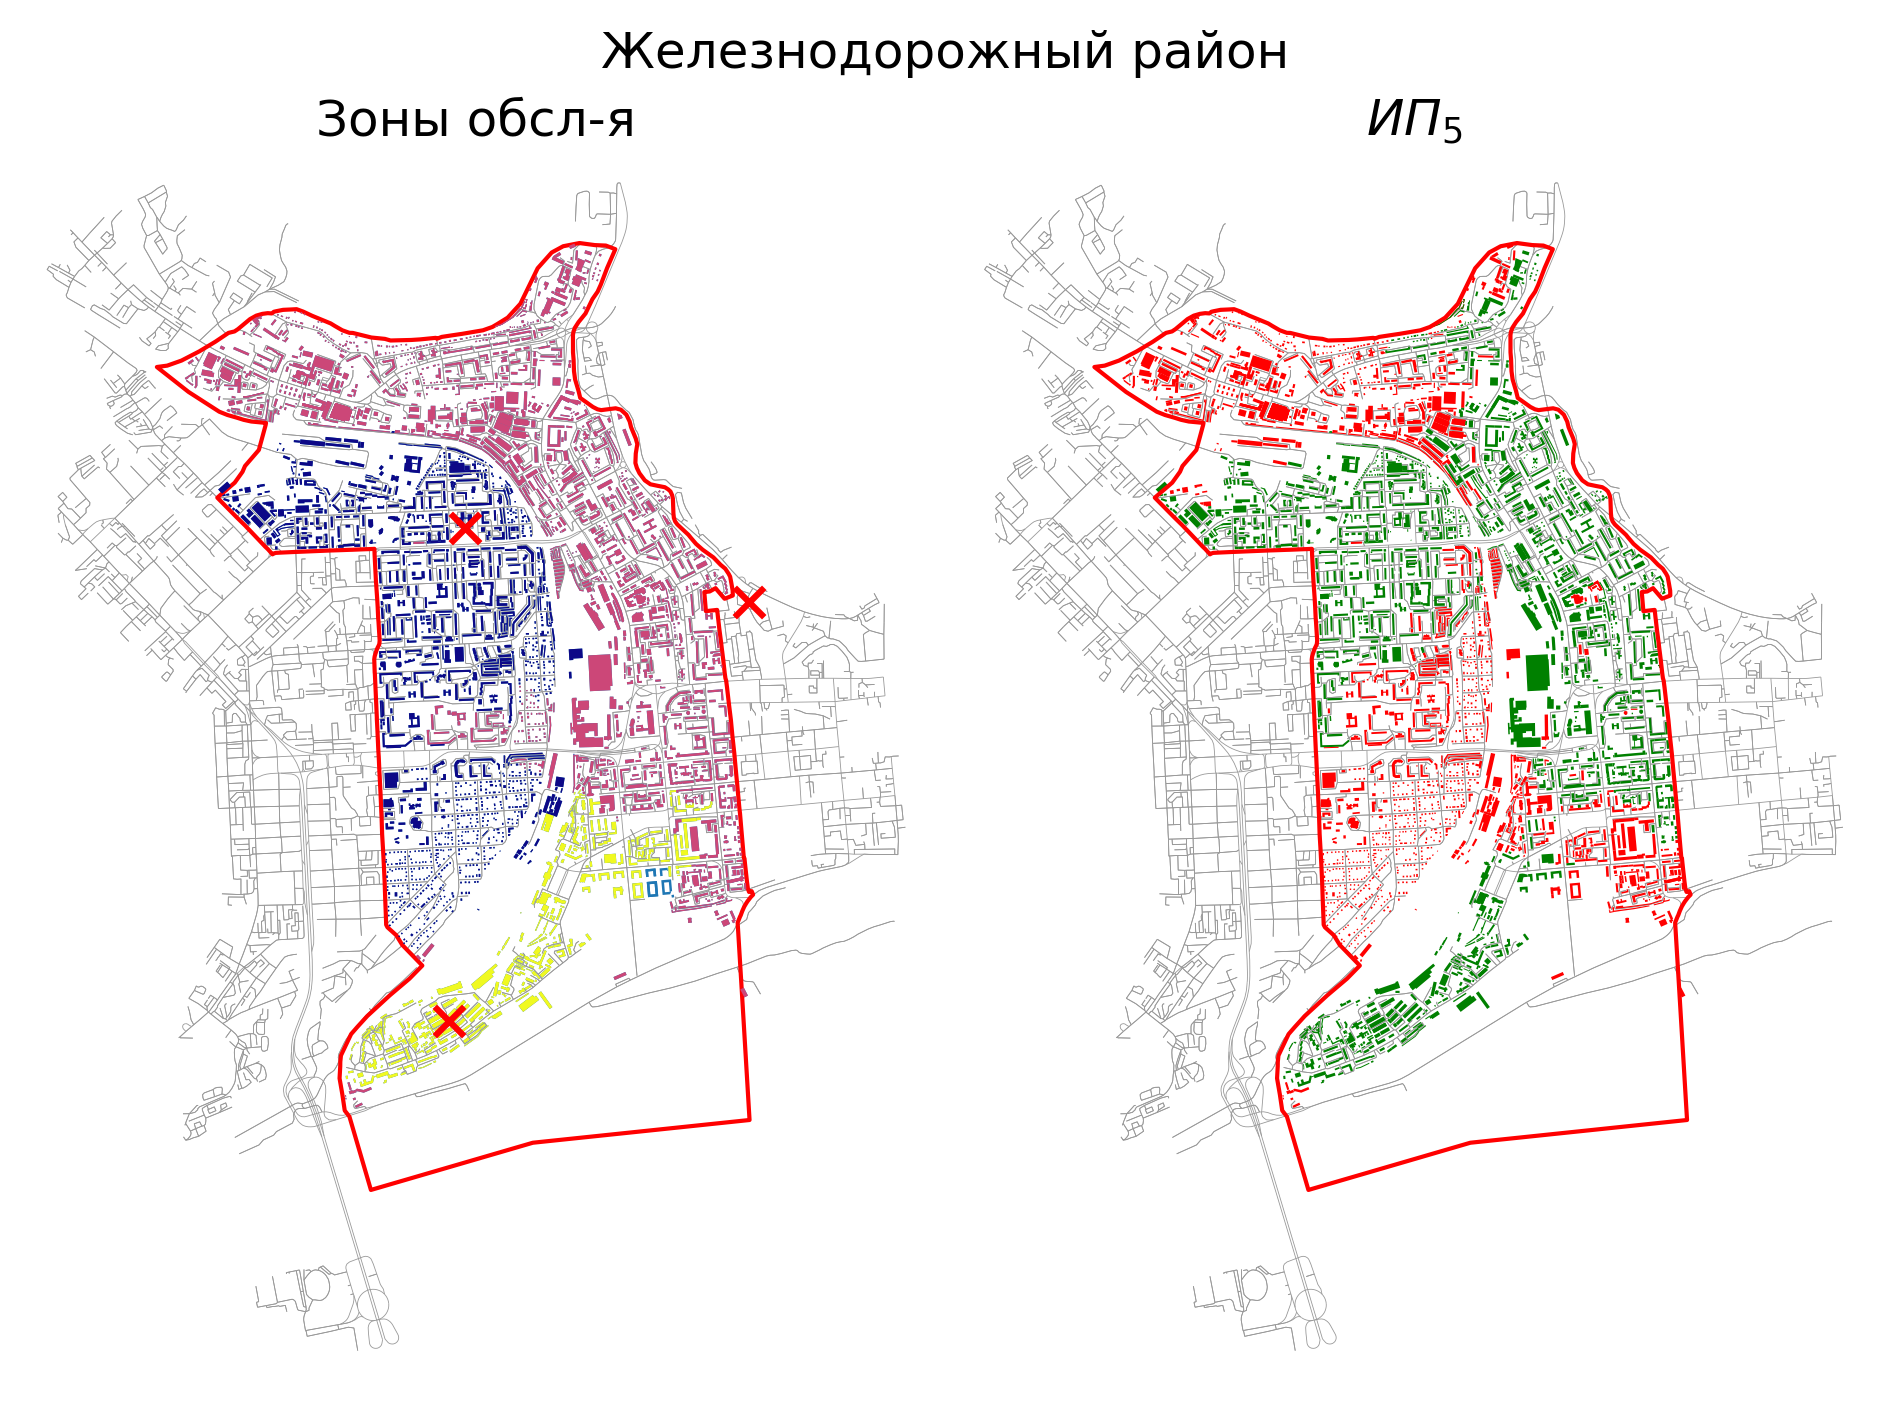

In [9]:
def plot_g2(name, g, b, poly, nodes, t_max=5, **kwds):
    
    fig, (ax, ax2) = plt.subplots(1,2, dpi=300, **kwds)

    ax.set_title('Зоны обсл-я')
    ax.set_axis_off()
    ax.set_facecolor('white')
    ox.plot_graph(g, node_size=0, edge_linewidth=0.2, ax=ax, show=False)
    b.plot(ax=ax)
    poly.plot(color='none', edgecolor='r', linewidth=1, ax=ax)



    ox.plot_graph(g, node_size=0, edge_linewidth=0.2, ax=ax2, show=False)
    times, nearest = FirstArrivalUnitState()(G, points=nodes)
    merged_df = pd.merge(b,
                pd.concat([times, nearest], axis=1),
                left_on=['node'],
                right_index=True)
    merged_df['time_color'] = ['green' if t<=t_max else 'red' for t in merged_df['times']]
    merged_df.plot(ax=ax, column='nearest', cmap='plasma')
    merged_df.plot(ax=ax2, color=merged_df['time_color'])
    poly.plot(color='none', edgecolor='r', linewidth=1, ax=ax2)

    g_nodes = ox.graph_to_gdfs(g, edges=False).loc[list(nodes.keys())]
    g_nodes.plot(ax=ax, color='r', markersize=50, marker='x', **kwds)
    
    ax2.set_title(f'$ИП_{t_max}$')
    ax2.set_axis_off()

    fig.suptitle(name)

    fig.tight_layout()
    plt.show()

# ТЕСТ, потом удалить!:
district = 'Железнодорожный район'
g = scopes[district][1]
b = scopes[district][2]
nodes = {list(g.nodes())[100]: '1', list(g.nodes())[200]: '2', list(g.nodes())[1000]: '3'}
plot_g2(district, g, b, districts.loc[[district]], nodes=nodes)

# Вычислительные эксперименты

## BLP

In [10]:
# Из кэша
tdfexisted = pd.read_csv('blp time.csv')
tdfexisted = tdfexisted.set_index('Unnamed: 0')
tdfexisted

,Железнодорожный район время,Кировский район время,Ленинский район время,Октябрьский район время,Свердловский район время,Железнодорожный район точность,Кировский район точность,Ленинский район точность,Октябрьский район точность,Свердловский район точность,Железнодорожный район точность2,Кировский район точность2,Ленинский район точность2,Октябрьский район точность2,Свердловский район точность2,Железнодорожный район узел,Кировский район узел,Ленинский район узел,Октябрьский район узел,Свердловский район узел
Unnamed: 0,,,,,,,,,,,,,,,,,,,,
Full,350.93,738.73,1415.35,2054.81,1336.11,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,345759063,2027464587,356754410,315787801,293390134.0
HC,8.20,14.50,20.10,21.80,15.30,40.5,0.0,0.0,21.4,5.0,111.4,105.1,103.2,111.3,113.1,345759063,356372571,291319488,8496337651,430030577.0
MSA,93.90,118.30,150.90,175.30,135.60,100.0,33.3,50.0,50.0,33.3,100.0,100.1,100.2,100.1,100.4,345759063,2027464587,356754410,315787801,316563423.0
HC+BNHD,2.61,13.90,3.04,9.54,25.33,115.9,101.2,100.4,100.0,100.0,115.9,101.2,100.4,100.0,100.0,1422785079,417834409,291319488,315787801,293390134.0
MSA+BNHD,184.40,249.60,336.10,236.80,234.10,100.0,0.0,100.0,100.0,100.0,100.0,100.2,100.0,100.0,100.0,345759063,356740734,356754410,315787801,293390134.0
ABC,37.50,43.90,67.10,69.00,56.30,100.0,28.6,40.0,40.0,66.7,100.0,100.2,100.2,100.1,100.3,345759063,356740734,356754410,315787800,293390134.0
SHS,76.50,138.80,268.10,203.70,NaN,100.0,0.0,0.0,100.0,NaN,100.0,100.3,100.4,100.0,NaN,345759063,356372571,965856797,315787801,NaN
SA,461.05,837.98,1007.55,1344.14,NaN,100.0,100.0,100.0,100.0,NaN,100.0,100.0,100.0,100.0,NaN,{345759063: 'best'},{2027464587: 'best'},{356754410: 'best'},{7027699260: 'best'},NaN


In [11]:
# # Из кэша
# tdfexisted = pd.read_csv('blp.csv')
# tdfexisted = tdfexisted.set_index('Unnamed: 0')


def save_experiment_state():
    # Сохранение итогов в основные словари:
    main_times_list[district+' время'] = times_list
    main_accuracy_list[district+' точность'] = accuracy_list
    main_accuracy2_list[district+' точность2'] = accuracy2_list
    main_best_node_list[district+' узел'] = best_node_list
    # ------------------------------
    tdf = pd.DataFrame({**main_times_list, **main_accuracy_list, **main_accuracy2_list, **main_best_node_list})
    tdf.to_csv('blp.csv')


main_times_list = {}
main_accuracy_list = {}
main_accuracy2_list = {}
main_best_node_list = {}

for district, scope in scopes.items():
    print(' ')
    print('='*80)
    print(district)
    g = scopes[district][1]
    b = scopes[district][2]
    nodes = ox.graph_to_gdfs(g, edges=False)
    area_nodes = nodes.within(scopes[district][0])
    nodes_list=set(nodes[area_nodes].index)
    print('Узлов', sum(area_nodes))
    print('='*80)

    # функция метрики спроса
    metric_demand = ArrivalTime()    # Demand(b, buildings_demand_field='kfpo_spros')

    # Списки результатов расчета
    times_list = {}
    accuracy_list = {}
    accuracy2_list = {}     # Для метрики по результату
    best_node_list = {}
    t = TimeCheckPoint()
    t2 = TimeCheckPoint()

    # Расчет полным перебором
    # ============================================================================
    print('\n', '# Расчет полным перебором')
    print('-'*80)
    try:
        accuracy_list['Full'] = tdfexisted.loc['Full'][district+' точность']
        accuracy2_list['Full'] = tdfexisted.loc['Full'][district+' точность2']
        times_list['Full'] = tdfexisted.loc['Full'][district+' время']
        best_node_list['Full'] = tdfexisted.loc['Full'][district+' узел']

        # Сохраняем эталонные значения
        etalon_node, etalon_time = best_node_list['Full'], times_list['Full']
        if np.isnan(etalon_time):
            raise ValueError('Значение не было вычислено!')
        etalon_node = int(float(etalon_node))
        etalon_metric = NodeMetric(FirstArrivalUnitState(), metric_demand)(g, etalon_node, area=area_nodes)
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        pb = Progressbar(sum(area_nodes), bins=40)
        full = BestNodesFull(FirstArrivalUnitState(), metric_demand, node_calc_end_function=pb)
        best_nodes, best_metric = full(env=g, area=area_nodes, nodes_list=nodes_list)
        time_spent = t()

        # Сохраняем результат вычисления
        times_list['Full'] = time_spent
        accuracy_list['Full'] = 100.0
        accuracy2_list['Full'] = 100.0
        best_node_list['Full'] = best_nodes[0]
        save_experiment_state()

        # Сохраняем эталонные значения
        etalon_metric = best_metric
        etalon_node, etalon_time = best_node_list['Full'], times_list['Full']
    

    print(f'ЭТАЛОННЫЙ УЗЕЛ: {etalon_node}')
    print(f'ЭТАЛОННАЯ МЕТРИКА: {etalon_metric}')
    print(f'РАСЧЕТНОЕ ВРЕМЯ: {etalon_time}')
    
    etalon_time = etalon_time if etalon_time < 300 else 300

    # Расчет HC
    # ============================================================================
    alg_name = 'HC'
    print('\n', f'# Расчет {alg_name}')
    print('-'*80)
    try:
        accuracy_list[alg_name] = tdfexisted.loc[alg_name][district+' точность']
        accuracy2_list[alg_name] = tdfexisted.loc[alg_name][district+' точность2']
        times_list[alg_name] = tdfexisted.loc[alg_name][district+' время']
        best_node_list[alg_name] = tdfexisted.loc[alg_name][district+' узел']
        if np.isnan(times_list[alg_name]):
            raise ValueError('Значение не было вычислено!')
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        bnhc = BestNodeHillClimbing(FirstArrivalUnitState(), metric_demand)
        bn_list = []
        bn_metrics = []
        i=1
        t()
        while t(False) < etalon_time:
            t2()
            start_node = random.choice(list(nodes_list))
            best_node, best_metric = bnhc(env=g, area=area_nodes, start_node=start_node)
            bn_list.append(best_node)
            bn_metrics.append(best_metric)
            print('\n', i, best_node, best_metric, t2(), end='\r')
            i+=1
        time_spent = t()

        # Сохраняем результат вычисления
        correct_results = bn_list.count(etalon_node)
        times_list[alg_name] = round(time_spent/len(bn_list), 1)
        accuracy_list[alg_name] = round(100*correct_results/len(bn_list), 1)
        accuracy2_list[alg_name] = round(100 * sum(bn_metrics) / (etalon_metric * len(bn_metrics)), 1)
        best_node_list[alg_name] = best_node
        save_experiment_state()
        print('\n')
    print(f'ТОЧНОСТЬ: {accuracy_list["HC"]}', '|', accuracy2_list['HC'])
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {times_list["HC"]} сек')

    # Расчет MSA
    # ============================================================================
    alg_name = 'MSA'
    print('\n', f'# Расчет {alg_name}')
    print('-'*80)
    try:
        accuracy_list[alg_name] = tdfexisted.loc[alg_name][district+' точность']
        accuracy2_list[alg_name] = tdfexisted.loc[alg_name][district+' точность2']
        times_list[alg_name] = tdfexisted.loc[alg_name][district+' время']
        best_node_list[alg_name] = tdfexisted.loc[alg_name][district+' узел']
        if np.isnan(times_list[alg_name]):
            raise ValueError('Значение не было вычислено!')
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        class EventFunc:
            def __init__(self):
                pass
            def __call__(self, **kwargs):
                global_jump_number = kwargs['global_jump_number']
                local_jump_number = kwargs.get('local_jump_number', 0)
                print("Глобальный прыжок:", global_jump_number, ", Локальный прыжок:", local_jump_number, '  ', end='\r')

        bnmsa = BestNodeMonkey(FirstArrivalUnitState(), metric_demand, 
                                    global_jumps_count=2,
                                    local_jumps_count=5,
                                    all_neighbors=True,
                                    after_global_jump_function=EventFunc(),
                                    after_local_jump_function=EventFunc(),
                                    )
        bn_list = []
        bn_metrics = []
        i=1
        t()
        while t(False) < etalon_time:
            t2()
            best_node, best_metric = bnmsa(env=g, area=area_nodes)
            bn_list.append(best_node)
            bn_metrics.append(best_metric)
            # print('\n', i, best_node, best_metric, t2(), end='\r')
            print(i, best_node, best_metric, t2())
            # print(etalon_metric)
            # print(bn_metrics)
            # print(100 * sum(bn_metrics))
            # print(etalon_metric * len(bn_metrics))
            # print(100 * sum(bn_metrics) / (etalon_metric * len(bn_metrics)))
            # print(round(100 * sum(bn_metrics) / (etalon_metric * len(bn_metrics)), 1))
            i+=1
        time_spent = t()

        # Сохраняем результат вычисления
        correct_results = bn_list.count(etalon_node)
        times_list['MSA'] = round(time_spent/len(bn_list), 1)
        accuracy_list['MSA'] = round(100*correct_results/len(bn_list),1)
        accuracy2_list['MSA'] = round(100 * sum(bn_metrics) / (etalon_metric * len(bn_metrics)), 1)
        best_node_list['MSA'] = best_node
        save_experiment_state()
        print('\n')
    print(f'ТОЧНОСТЬ: {accuracy_list["MSA"]}', '|', accuracy2_list['MSA'])
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {times_list["MSA"]} сек')

    # Расчет HC+BNHD
    # ============================================================================
    alg_name = 'HC+BNHD'
    print('\n', f'# Расчет {alg_name}')
    print('-'*80)
    try:
        accuracy_list[alg_name] = tdfexisted.loc[alg_name][district+' точность']
        accuracy2_list[alg_name] = tdfexisted.loc[alg_name][district+' точность2']
        times_list[alg_name] = tdfexisted.loc[alg_name][district+' время']
        best_node_list[alg_name] = tdfexisted.loc[alg_name][district+' узел']
        if np.isnan(times_list[alg_name]):
            raise ValueError('Значение не было вычислено!')
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        bnhd = BestNodesHalfDiameter(FirstArrivalUnitState(), metric_demand)
        bnhc = BestNodeHillClimbing(FirstArrivalUnitState(), metric_demand)

        t()
        start_node = bnhd(env=g, area=area_nodes)
        best_node, best_metric = bnhc(env=g, area=area_nodes, start_node=start_node)
        time_spent = t()

        # Сохраняем результат вычисления
        correct_results = best_metric/etalon_metric
        times_list['HC+BNHD'] = time_spent
        accuracy_list['HC+BNHD'] = round(100*correct_results,1)
        accuracy2_list['HC+BNHD'] = round(100*correct_results,1)
        best_node_list['HC+BNHD'] = best_node
        save_experiment_state()
        print('\n')
    print(f'ТОЧНОСТЬ: {accuracy_list["HC+BNHD"]}', '|', accuracy2_list['HC+BNHD'])
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {times_list["HC+BNHD"]} сек')


    # Расчет MSA+BNHD
    # ============================================================================
    alg_name = 'MSA+BNHD'
    print('\n', f'# Расчет {alg_name}')
    print('-'*80)
    try:
        accuracy_list[alg_name] = tdfexisted.loc[alg_name][district+' точность']
        accuracy2_list[alg_name] = tdfexisted.loc[alg_name][district+' точность2']
        times_list[alg_name] = tdfexisted.loc[alg_name][district+' время']
        best_node_list[alg_name] = tdfexisted.loc[alg_name][district+' узел']
        if np.isnan(times_list[alg_name]):
            raise ValueError('Значение не было вычислено!')
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        bnhd = BestNodesHalfDiameter(FirstArrivalUnitState(), metric_demand)
        bnmsa = BestNodeMonkey(FirstArrivalUnitState(), metric_demand, 
                                global_jumps_count=2,
                                local_jumps_count=10,
                                all_neighbors=True,
                                local_jump_max_distance=1500,
                                after_global_jump_function=EventFunc(),
                                after_local_jump_function=EventFunc(),
                                )

        bn_list = []
        bn_metrics = []
        i=1
        t()
        while t(False) < etalon_time:
            t2()
            start_node = bnhd(env=g, area=area_nodes)
            best_node, best_metric = bnmsa(env=g, area=area_nodes, start_node=start_node)
            bn_list.append(best_node)
            bn_metrics.append(best_metric)
            print('\n', i, best_node, best_metric, t2(), end='\r')
            i+=1
        time_spent = t()

        # Сохраняем результат вычисления
        correct_results = bn_list.count(etalon_node)
        times_list['MSA+BNHD'] = round(time_spent/len(bn_list), 1)
        accuracy_list['MSA+BNHD'] = round(100*correct_results/len(bn_list),1)
        accuracy2_list['MSA+BNHD'] = round(100 * sum(bn_metrics) / (etalon_metric * len(bn_metrics)), 1)
        best_node_list['MSA+BNHD'] = best_node
        save_experiment_state()
        print('\n')
    print(f'ТОЧНОСТЬ: {accuracy_list["MSA+BNHD"]}', '|', accuracy2_list['MSA+BNHD'])
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {times_list["MSA+BNHD"]} сек')






    # Расчет ABC
    # ============================================================================
    alg_name = 'ABC'
    print('\n', f'# Расчет {alg_name}')
    print('-'*80)
    try:
        accuracy_list[alg_name] = tdfexisted.loc[alg_name][district+' точность']
        accuracy2_list[alg_name] = tdfexisted.loc[alg_name][district+' точность2']
        times_list[alg_name] = tdfexisted.loc[alg_name][district+' время']
        best_node_list[alg_name] = tdfexisted.loc[alg_name][district+' узел']
        if np.isnan(times_list[alg_name]):
            raise ValueError('Значение не было вычислено!')
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        bnabc = BestNodeBee(FirstArrivalUnitState(),
                        metric_demand,
                        # scouts_count=150,
                        # best_scouts_count=3,
                        )
        bn_list = []
        bn_metrics = []
        i=1
        t()
        while t(False) < etalon_time:
            t2()
            best_node, best_metric = bnabc(env=g, area=area_nodes, nodes_list=nodes_list)
            bn_list.append(best_node)
            bn_metrics.append(best_metric)
            print('\n', i, best_node, best_metric, t2(), end='\r')
            i+=1
        time_spent = t()

        # Сохраняем результат вычисления
        correct_results = bn_list.count(etalon_node)
        times_list['ABC'] = round(time_spent/len(bn_list), 1)
        accuracy_list['ABC'] = round(100*correct_results/len(bn_list),1)
        accuracy2_list['ABC'] = round(100 * sum(bn_metrics) / (etalon_metric * len(bn_metrics)), 1)
        best_node_list['ABC'] = best_node
        save_experiment_state()
        print('\n')
    print(f'ТОЧНОСТЬ: {accuracy_list["ABC"]}', '|', accuracy2_list['ABC'])
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {times_list["ABC"]} сек')

    # Расчет SHS
    # ============================================================================
    alg_name = 'SHS'
    print('\n', f'# Расчет {alg_name}')
    print('-'*80)
    try:
        accuracy_list[alg_name] = tdfexisted.loc[alg_name][district+' точность']
        accuracy2_list[alg_name] = tdfexisted.loc[alg_name][district+' точность2']
        times_list[alg_name] = tdfexisted.loc[alg_name][district+' время']
        best_node_list[alg_name] = tdfexisted.loc[alg_name][district+' узел']
        if np.isnan(times_list[alg_name]):
            raise ValueError('Значение не было вычислено!')
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        bnabc = BestNodeBee(FirstArrivalUnitState(),
                        metric_demand,
                        scouts_count=10,
                        best_scouts_count=10,
                        )
        bn_list = []
        bn_metrics = []
        i=1
        t()
        while t(False) < etalon_time:
            t2()
            best_node, best_metric = bnabc(env=g, area=area_nodes, nodes_list=nodes_list)
            bn_list.append(best_node)
            bn_metrics.append(best_metric)
            print('\n', i, best_node, best_metric, t2(), end='\r')
            i+=1
        time_spent = t()

        # Сохраняем результат вычисления
        correct_results = bn_list.count(etalon_node)
        times_list['SHS'] = round(time_spent/len(bn_list), 1)
        accuracy_list['SHS'] = round(100*correct_results/len(bn_list),1)
        accuracy2_list['SHS'] = round(100 * sum(bn_metrics) / (etalon_metric * len(bn_metrics)), 1)
        best_node_list['SHS'] = best_node
        save_experiment_state()
        print('\n')
    print(f'ТОЧНОСТЬ: {accuracy_list["SHS"]}', '|', accuracy2_list['SHS'])
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {times_list["SHS"]} сек')

    # Расчет SA
    # ============================================================================
    alg_name = 'SA'
    print('\n', f'# Расчет {alg_name}')
    print('-'*80)
    try:
        accuracy_list[alg_name] = tdfexisted.loc[alg_name][district+' точность']
        accuracy2_list[alg_name] = tdfexisted.loc[alg_name][district+' точность2']
        times_list[alg_name] = tdfexisted.loc[alg_name][district+' время']
        best_node_list[alg_name] = tdfexisted.loc[alg_name][district+' узел']
        if np.isnan(times_list[alg_name]):
            raise ValueError('Значение не было вычислено!')
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:

        def best_state_find_function(turn:int, T:float, best_metric:float, cur_metric:float, best_bot:dict):
            print(f'\nШаг: {turn} |', f'T={T} |', f'Лучшая метрика: {best_metric} |', f'Лучшее положение: {best_bot} |')
        def turn_end_function(turn:int, T:float, best_metric:float, cur_metric:float, best_bot:dict):
            print(f'Шаг: {turn} |', f'T={round(T,5)} |', 
                  f'Лучшая метрика: {best_metric} |',
                  f'Текущая метрика: {cur_metric} |',
                  f'Лучшее положение: {best_bot} |',
                  end='\r')        

        node_selector = RandomNodesSelector(nodes_list=nodes_list)
        stop_case = NSameStopCase(n=2000)
        mclpsa = BestNodesSA(FirstArrivalUnitState(),
                            metric_demand,
                            node_selector=node_selector,
                            end_temperature=0.0001,
                            turns= 10000,
                             turn_end_function=turn_end_function,
                            # best_state_find_function=best_state_find_function,
                            stop_case_function=stop_case
                            )

        t()
        # best_node, best_metric = mclpsa(env=g, area=area_nodes, start_node=start_node)
        print({list(g.nodes())[0]:'best'})
        best_node, best_metric = mclpsa(env=g, area=area_nodes, dynamic_nodes={list(g.nodes())[0]:'best'})
        time_spent = t()

        # Сохраняем результат вычисления
        correct_results = best_metric/etalon_metric
        times_list['SA'] = time_spent
        accuracy_list['SA'] = round(100*correct_results,1)
        accuracy2_list['SA'] = round(100*correct_results,1)
        best_node_list['SA'] = best_node
        save_experiment_state()
        print('\n')
    print(f'ТОЧНОСТЬ: {accuracy_list["SA"]}', '|', accuracy2_list['SA'])
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {times_list["SA"]} сек')

    # ======================================================================
    # Сохранение итогов в основные словари:
    save_experiment_state()

    # До этого:
    # main_times_list[district+' время'] = times_list
    # main_accuracy_list[district+' точность'] = accuracy_list
    # main_accuracy2_list[district+' точность2'] = accuracy2_list
    # main_best_node_list[district+' узел'] = best_node_list
    # # Промежуточное сохранение в DataFrame с объединением main_times_list и main_accuracy_list
    # # ------------------------------
    # # tdf_times = pd.DataFrame(main_times_list)
    # # tdf_times.to_csv('times.csv')
    # # tdf_accuracy = pd.DataFrame(main_accuracy_list)
    # # tdf_accuracy.to_csv('accuracy.csv')
    # tdf = pd.DataFrame({**main_times_list, **main_accuracy_list, **main_accuracy2_list, **main_best_node_list})
    # tdf.to_csv('metrics.csv')
    # # tdf.to_csv(f'{district}.csv')

    

 
Железнодорожный район
Узлов 1861

 # Расчет полным перебором
--------------------------------------------------------------------------------
ИМЕЕТСЯ В КЭШЕ!
ЭТАЛОННЫЙ УЗЕЛ: 345759063
ЭТАЛОННАЯ МЕТРИКА: 4.280868761150899
РАСЧЕТНОЕ ВРЕМЯ: 350.93

 # Расчет HC
--------------------------------------------------------------------------------
ИМЕЕТСЯ В КЭШЕ!
ТОЧНОСТЬ: 40.5 | 111.4
ВРЕМЯ ОДНОГО РАСЧЕТА: 8.2 сек

 # Расчет MSA
--------------------------------------------------------------------------------
ИМЕЕТСЯ В КЭШЕ!
ТОЧНОСТЬ: 100.0 | 100.0
ВРЕМЯ ОДНОГО РАСЧЕТА: 93.9 сек

 # Расчет HC+BNHD
--------------------------------------------------------------------------------
ИМЕЕТСЯ В КЭШЕ!
ТОЧНОСТЬ: 115.9 | 115.9
ВРЕМЯ ОДНОГО РАСЧЕТА: 2.61 сек

 # Расчет MSA+BNHD
--------------------------------------------------------------------------------
ИМЕЕТСЯ В КЭШЕ!
ТОЧНОСТЬ: 100.0 | 100.0
ВРЕМЯ ОДНОГО РАСЧЕТА: 184.4 сек

 # Расчет ABC
---------------------------------------------------------------

## MCLP

In [ ]:
# Из кэша
tdfexisted = pd.read_csv('mclp.csv')
tdfexisted = tdfexisted.set_index('Unnamed: 0')
# tdfexisted = tdfexisted.drop('GA+GNS')
tdfexisted

In [10]:

def save_experiment_mclp_state():
    # # Сохранение итогов в основные словари:
    # main_times_list[district+' время'] = times_list
    # main_accuracy_list[district+' точность'] = accuracy_list
    # main_accuracy2_list[district+' точность2'] = accuracy2_list
    # main_best_node_list[district+' узел'] = best_node_list
    # # ------------------------------
    # tdf = pd.DataFrame({**main_times_list, **main_accuracy_list, **main_accuracy2_list, **main_best_node_list})
    # tdf.to_csv('blp.csv')
    # Сохранение итогов в основные словари:
    main_times_list[district+' время'] = times_list
    main_metrics_list[district+' точность'] = metrics_list
    # Промежуточное сохранение в DataFrame с объединением main_times_list и main_metrics_list
    # ------------------------------
    tdf = pd.DataFrame({**main_times_list, **main_metrics_list})
    tdf.to_csv('mclp.csv')



main_times_list = {}
main_metrics_list = {}

units_count = 3

for district, scope in scopes.items():
    print(' ')
    print('='*80)
    print(district)
    g = scopes[district][1]
    b = scopes[district][2]
    nodes = ox.graph_to_gdfs(g, edges=False)
    area_nodes = nodes.within(scopes[district][0])
    nodes_list=set(nodes[area_nodes].index)
    start_state = {random.sample(list(nodes_list), k=1)[0]:f'псч {i}' for i in range(units_count)}
    print('Узлов', sum(area_nodes))
    print('='*80)

    # функция метрики спроса
    metric_demand = ArrivalTime()  # Demand(b, buildings_demand_field='kfpo_spros')

    # Списки результатов расчета
    times_list = {}
    metrics_list = {}

    # Расчет SA
    # ============================================================================
    print('\n', '# SA')
    print('-'*80)

    try:
        best_metric = tdfexisted.loc['SA'][district+' точность']
        time_spent = tdfexisted.loc['SA'][district+' время']
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        t = TimeCheckPoint()
        t2 = TimeCheckPoint()

        # здесь сам расчет
        def turn_end_function(turn:int, T:float, best_metric:float, cur_metric:float, best_bot:dict):
            print(f'Шаг: {turn} |', f'T={T} |', f'Лучшая метрика: {best_metric} |', f'Лучшее положение: {best_bot} |', ' '*10, end='\r')
        def best_state_find_function(turn:int, T:float, best_metric:float, cur_metric:float, best_bot:dict):
            print(f'\nШаг: {turn} |', f'T={T} |', f'Лучшая метрика: {best_metric} |', f'Лучшее положение: {best_bot} |')
        point_selector = RandomNodesSelector(nodes_list=nodes_list)
        stop_case = NSameStopCase(n=2000)
        mclpsa = BestNodesSA(FirstArrivalUnitState(),
                            metric_demand,
                            node_selector = point_selector,
                            end_temperature = 0.0001,
                            turns = 10000,
                            mutation_max_count = 2,
                            turn_end_function=turn_end_function,
                            # best_state_find_function = best_state_find_function,
                            stop_case_function = stop_case
                            )
        best_state, best_metric = mclpsa(env=g, area=area_nodes, dynamic_nodes=start_state)

        # завершающая стадия расчета
        time_spent = t()
        print('\n')
    print(f'ЛУЧШИЙ РЕЗУЛЬТАТ: {best_metric}')
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {time_spent} сек')

    # Сохраняем результат вычисления
    times_list['SA'] = time_spent
    metrics_list['SA'] = best_metric
    save_experiment_mclp_state()

    # Расчет GA
    # ============================================================================
    print('\n', '# GA')
    print('-'*80)
    try:
        best_metric = tdfexisted.loc['GA'][district+' точность']
        time_spent = tdfexisted.loc['GA'][district+' время']
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        t = TimeCheckPoint()
        # t2 = TimeCheckPoint()

        # здесь сам расчет
        def epoch_end_function(epoch, best_metric, cur_metric, **kwargs):
            print(f'Эпоха: {epoch} |', f'Лучшая метрика: {best_metric} |', f'Текущая метрика: {cur_metric} |', ' '*10, end='\r')
        point_selector = RandomNodesSelector(nodes_list=nodes_list)
        stop_case = NSameStopCase(n=20)
        mclpga = BestNodesGA(FirstArrivalUnitState(),
                        metric_demand,
                        node_selector = point_selector,
                        population_size=50,
                        elite_size=15,
                        epochs=30,
                        mutation_rate=0.5,
                        mutation_max_count=3,
                        epoch_end_function=epoch_end_function,
                        # stop_case_function = stop_case
                        )
        optimal_nodes, best_metric = mclpga(env=g, 
                                    dynamic_nodes=start_state,
                                    area=area_nodes,
                                    )

        # завершающая стадия расчета
        time_spent = t()
        print('\n')
    print(f'ЛУЧШИЙ РЕЗУЛЬТАТ: {best_metric}')
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {time_spent} сек')

    # Сохраняем результат вычисления
    times_list['GA'] = time_spent
    metrics_list['GA'] = best_metric
    save_experiment_mclp_state()


    # Расчет GNS
    # ============================================================================
    print('\n', '# GNS')
    print('-'*80)
    try:
        best_metric = tdfexisted.loc['GNS'][district+' точность']
        time_spent = tdfexisted.loc['GNS'][district+' время']
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        t = TimeCheckPoint()
        # t2 = TimeCheckPoint()

        # здесь сам расчет
        def iter_func(i, best_metric, **kwds):
            print(i, ':', best_metric, end='\r')
        bnhc = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                        metric_function=metric_demand,
                        )
        mclpgns = BestNodesKoptG(state_function=FirstArrivalUnitState(),
                        metric_function=metric_demand,
                        best_point_function=bnhc,
                        iterations=5,
                        iter_calc_end_function=iter_func,
                        )
        optimal_nodes, best_metric = mclpgns(env=g,
                            dynamic_nodes=start_state,
                            area=area_nodes,
                            )

        # завершающая стадия расчета
        time_spent = t()
        print('\n')
    print(f'ЛУЧШИЙ РЕЗУЛЬТАТ: {best_metric}')
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {time_spent} сек')

    # Сохраняем результат вычисления
    times_list['GNS'] = time_spent
    metrics_list['GNS'] = best_metric
    save_experiment_mclp_state()


    # Расчет GNS+BNHD
    # ============================================================================
    alg_name = 'GNS+BNHD'
    print('\n', f'# {alg_name}')
    print('-'*80)
    try:
        best_metric = tdfexisted.loc[alg_name][district+' точность']
        time_spent = tdfexisted.loc[alg_name][district+' время']
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        t = TimeCheckPoint()
        # t2 = TimeCheckPoint()

        # здесь сам расчет
        def iter_func(i, best_metric, **kwds):
            print(i, ':', best_metric, end='\r')
        bnhc = BestNodeHillClimbingHD(state_function=FirstArrivalUnitState(),
                        metric_function=metric_demand,
                        )
        mclpgns = BestNodesKoptG(state_function=FirstArrivalUnitState(),
                        metric_function=metric_demand,
                        best_point_function=bnhc,
                        iterations=5,
                        iter_calc_end_function=iter_func,
                        )
        optimal_nodes, best_metric = mclpgns(env=g,
                            dynamic_nodes=start_state,
                            area=area_nodes,
                            )

        # завершающая стадия расчета
        time_spent = t()
        print('\n')
    print(f'ЛУЧШИЙ РЕЗУЛЬТАТ: {best_metric}')
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {time_spent} сек')

    # Сохраняем результат вычисления
    times_list[alg_name] = time_spent
    metrics_list[alg_name] = best_metric
    save_experiment_mclp_state()


    # Расчет GA+GNS
    # ============================================================================
    print('\n', '# GA+GNS')
    print('-'*80)
    try:
        best_metric = tdfexisted.loc['GA+GNS'][district+' точность']
        time_spent = tdfexisted.loc['GA+GNS'][district+' время']
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        t = TimeCheckPoint()
        # t2 = TimeCheckPoint()

        # здесь сам расчет
        def epoch_end_function(epoch, best_metric, cur_metric, **kwargs):
            print(f'Эпоха: {epoch} |', f'Лучшая метрика: {best_metric} |', f'Текущая метрика: {cur_metric} |', ' '*10, end='\r')
        def iter_calc_end_function(i, best_metric, **kwargs):
            print(f'Итерация: {i} |', f'Лучшая метрика: {best_metric} |', ' '*10)  #, end='\r')
        # optimal_nodes, best_metric = mclpga(env=g, 
        #                               dynamic_nodes=start_state,
        #                               area=area_nodes,
        #                               )
        # optimal_nodes, best_metric = mclpgns(env=g,
        #                     dynamic_nodes=optimal_nodes,
        #                     area=area_nodes,
        #                     )
        bnhc = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                    metric_function=metric_demand,                      
                        )
        kopt = BestNodesKoptG(FirstArrivalUnitState(),
                            metric_function=metric_demand,
                            best_point_function=bnhc,
                            iterations=3,
                            iter_calc_end_function=iter_calc_end_function,
                            )
        point_selector = RandomNodesSelector(nodes_list=nodes_list)
        stop_case = NSameStopCase(n=20)
        mclp = timing(BestNodesGAKopt(FirstArrivalUnitState(),
                            metric_function=metric_demand,
                            kopt_function = kopt,
                            node_selector = point_selector,
                            population_size=50,
                            elite_size = 15,
                            epochs = 30,
                            mutation_rate = 0.5,
                            mutation_max_count=3,
                            epoch_end_function = epoch_end_function,
                            #    stop_case_function=stop_case,
        ))

        # Собственно применения построенного алгоритма
        optimal_nodes, best_metric = mclp(env=g,
                                    #   static_nodes=existed_units, 
                                    dynamic_nodes=start_state,
                                    area=area_nodes,
                                    )

        # завершающая стадия расчета
        time_spent = t()
        print('\n')
    print(f'ЛУЧШИЙ РЕЗУЛЬТАТ: {best_metric}')
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {time_spent} сек')

    # Сохраняем результат вычисления
    times_list['GA+GNS'] = time_spent
    metrics_list['GA+GNS'] = best_metric
    save_experiment_mclp_state()




    # # Сохранение итогов в основные словари:
    # main_times_list[district+' время'] = times_list
    # main_metrics_list[district+' точность'] = metrics_list
    
    # # Промежуточное сохранение в DataFrame с объединением main_times_list и main_metrics_list
    # # ------------------------------
    # tdf = pd.DataFrame({**main_times_list, **main_metrics_list})
    # tdf.to_csv('mclp.csv')
    # # tdf.to_csv(f'mclp {district}.csv')



 
Железнодорожный район
Узлов 1861

 # SA
--------------------------------------------------------------------------------
Шаг: 5043 | T=0.00019825535289452815 | Лучшая метрика: 3.1881253434334025 | Лучшее положение: {5579242366: 'псч 1', 4550836107: 'псч 0', 4064665433: 'псч 2'} |           

ЛУЧШИЙ РЕЗУЛЬТАТ: 3.1881253434334025
ВРЕМЯ ОДНОГО РАСЧЕТА: 979.43 сек

 # GA
--------------------------------------------------------------------------------
Эпоха: 29 | Лучшая метрика: 3.2594535343029376 | Текущая метрика: 3.2594535343029376 |           

ЛУЧШИЙ РЕЗУЛЬТАТ: 3.2594535343029376
ВРЕМЯ ОДНОГО РАСЧЕТА: 302.46 сек

 # GNS
--------------------------------------------------------------------------------
4 : 3.1547185013477284

ЛУЧШИЙ РЕЗУЛЬТАТ: 3.154718501347728
ВРЕМЯ ОДНОГО РАСЧЕТА: 15.78 сек

 # GNS+BNHD
--------------------------------------------------------------------------------
4 : 3.8026861516973396

ЛУЧШИЙ РЕЗУЛЬТАТ: 3.8026861516973396
ВРЕМЯ ОДНОГО РАСЧЕТА: 24.72 сек

 # GA+GNS

In [ ]:
tdfexisted = pd.read_csv('mclp.csv')
tdfexisted = tdfexisted.set_index('Unnamed: 0')
tdfexisted = tdfexisted.drop('GA+GNS')
tdfexisted

## LSCP

In [ ]:
# Из кэша
tdfexisted = pd.concat([pd.read_csv('lscp copy.csv'), pd.read_csv('lscp copy 2.csv')], axis=1)
tdfexisted = tdfexisted.set_index('Unnamed: 0')
# tdfexisted = tdfexisted.drop('Ленинский район время', axis=1)
# tdfexisted = tdfexisted.drop('Ленинский район метрика', axis=1)
# tdfexisted = tdfexisted.drop('Ленинский район подразделений', axis=1)
tdfexisted

 
Железнодорожный район
Узлов 1861

 # Расчет GNS
--------------------------------------------------------------------------------
4 4.654717312972656
Итерация: 0 | Лучшая метрика: 4.654717312972656 | Подразделений: 2
Текущий ИП-5: 55.146798726565265 90
4 3.5125315165253337
Итерация: 1 | Лучшая метрика: 3.5125315165253337 | Подразделений: 3
Текущий ИП-5: 86.02759108595684 90
4 3.1786329256375168
Итерация: 2 | Лучшая метрика: 3.1786329256375168 | Подразделений: 4
Текущий ИП-5: 90.06013441811108 90
Текущий ИП-5: 90.06013441811108 90
Текущий ИП-5: 84.64803678811461 90
Текущий ИП-5: 84.64803678811461 90
Текущий ИП-5: 84.64803678811461 90
 -> 1 Подразделений: 3 84.64803678811461 66.12
4 3.748734035311522
Итерация: 0 | Лучшая метрика: 3.74873403531152 | Подразделений: 2
Текущий ИП-5: 65.33427661832332 90
4 3.509574327988004
Итерация: 1 | Лучшая метрика: 3.509574327988004 | Подразделений: 3
Текущий ИП-5: 70.74637424831977 90
4 3.081855462773332
Итерация: 2 | Лучшая метрика: 3.081855462773332 

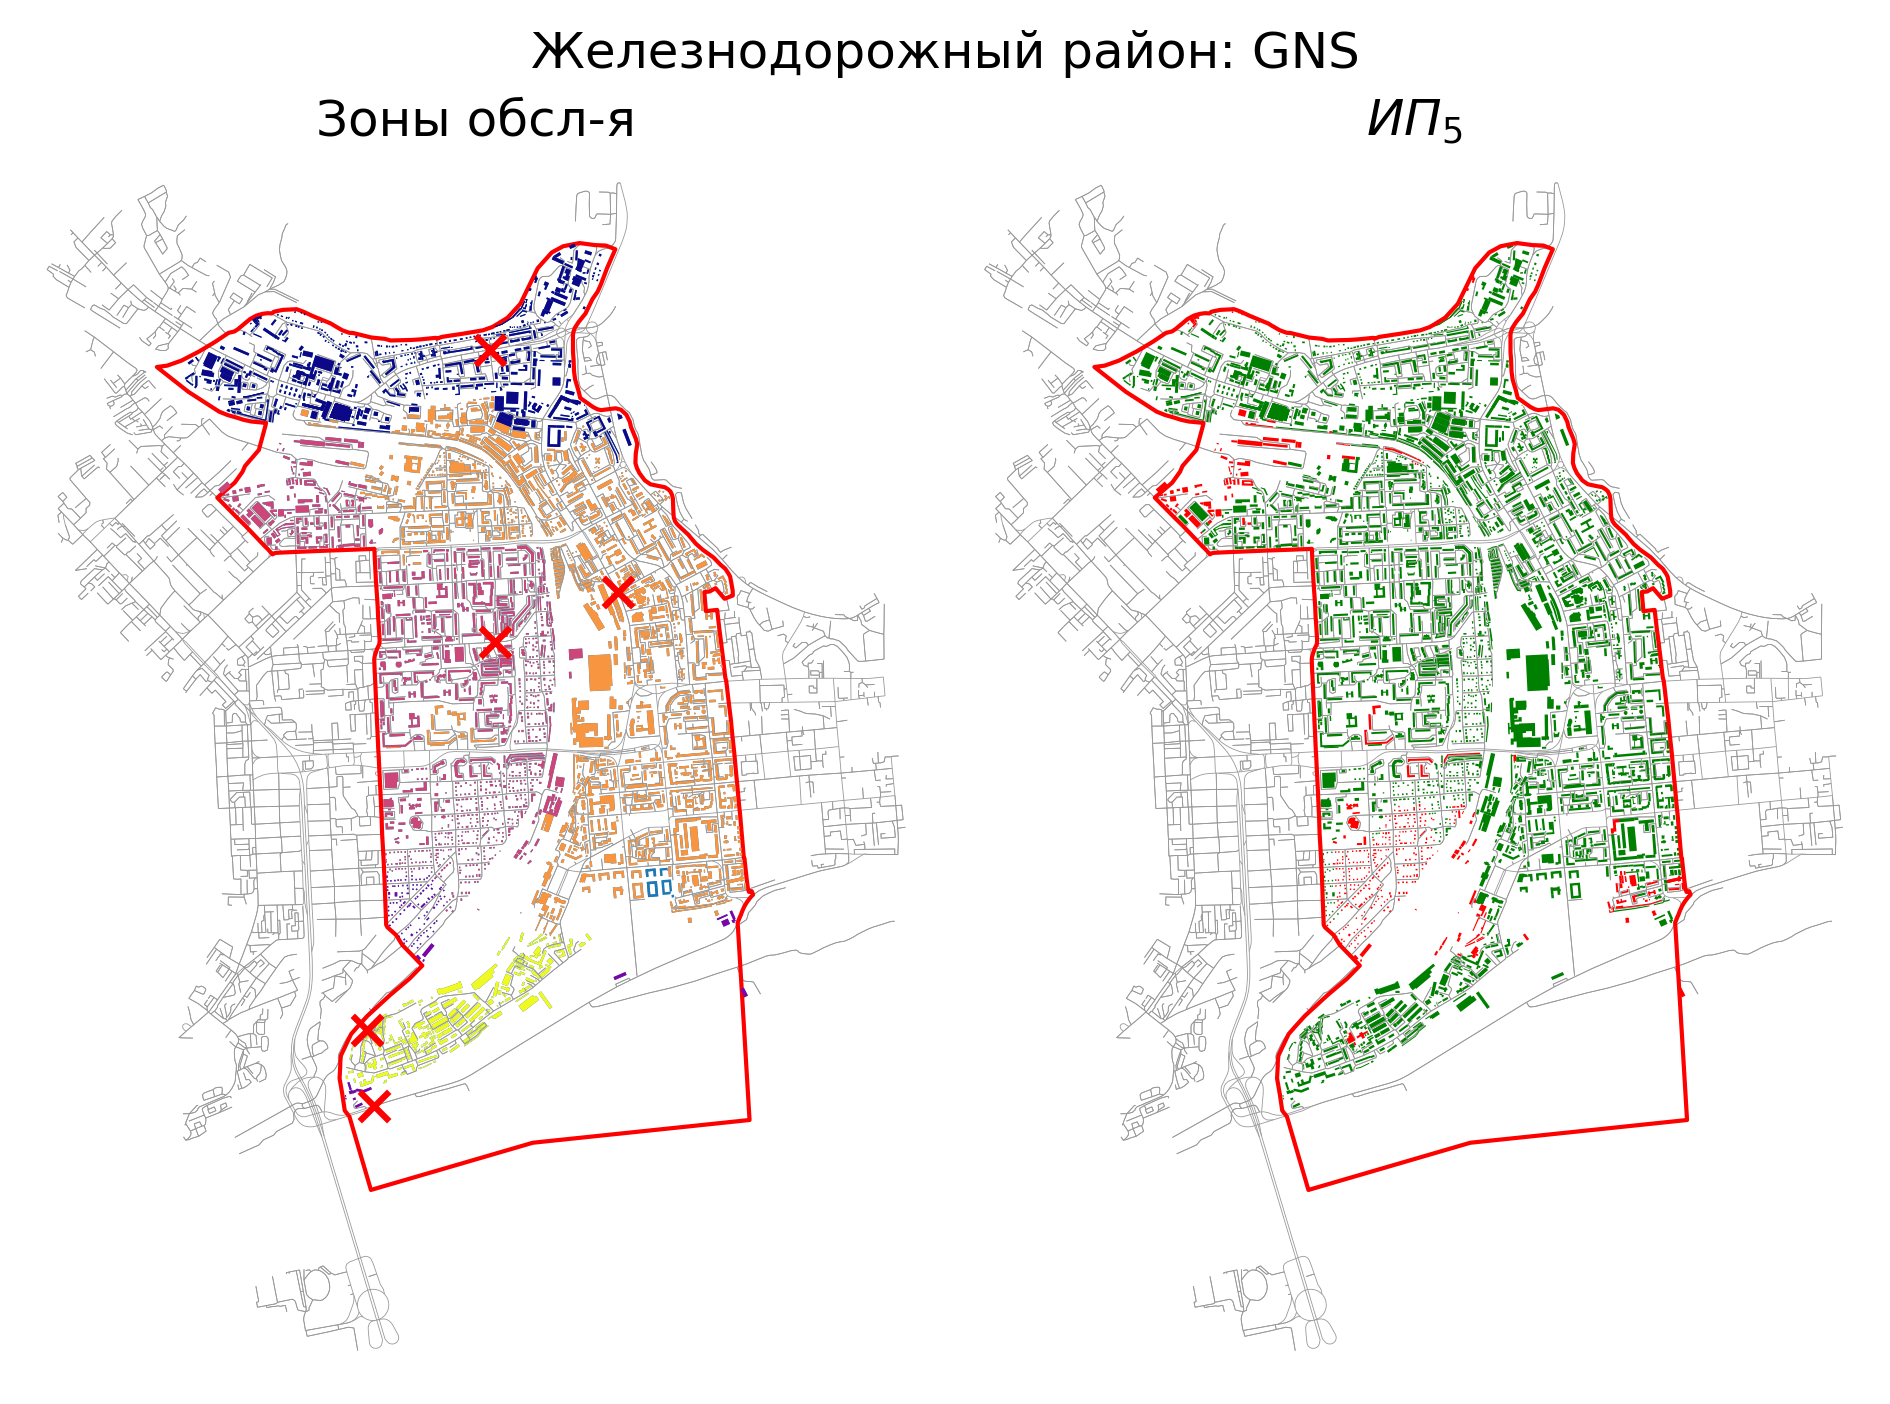



МЕТРИКА: 84.22355854262469 | ПОДРАЗДЕЛЕНИЙ 3
ВРЕМЯ ОДНОГО РАСЧЕТА: 66.12 сек

 # Расчет GA+GNS
--------------------------------------------------------------------------------
2 3.6021398746407858трика: 3.7422530980818776 | Текущая метрика: 3.7422530980818776 |           
Итерация: 0 | Лучшая метрика: 3.6021398746407858 | Подразделений: 2
Текущий ИП-5: 70.85249380969225 90
2 3.1943951876311023трика: 3.221750282306173 | Текущая метрика: 3.221750282306173 |             
Итерация: 1 | Лучшая метрика: 3.1943951876311023 | Подразделений: 3
Текущий ИП-5: 89.0696851786346 90
2 2.8690102097769836трика: 2.979217979917933 | Текущая метрика: 2.979217979917933 |             
Итерация: 2 | Лучшая метрика: 2.8690102097769836 | Подразделений: 4
Текущий ИП-5: 93.10222851078882 90
Текущий ИП-5: 93.10222851078882 90
Текущий ИП-5: 85.95684471170853 90
Текущий ИП-5: 85.95684471170853 90
Текущий ИП-5: 85.95684471170853 90
 -> 1 Подразделений: 3 85.95684471170853 366.67
2 3.6021398746407858трика: 3.658098

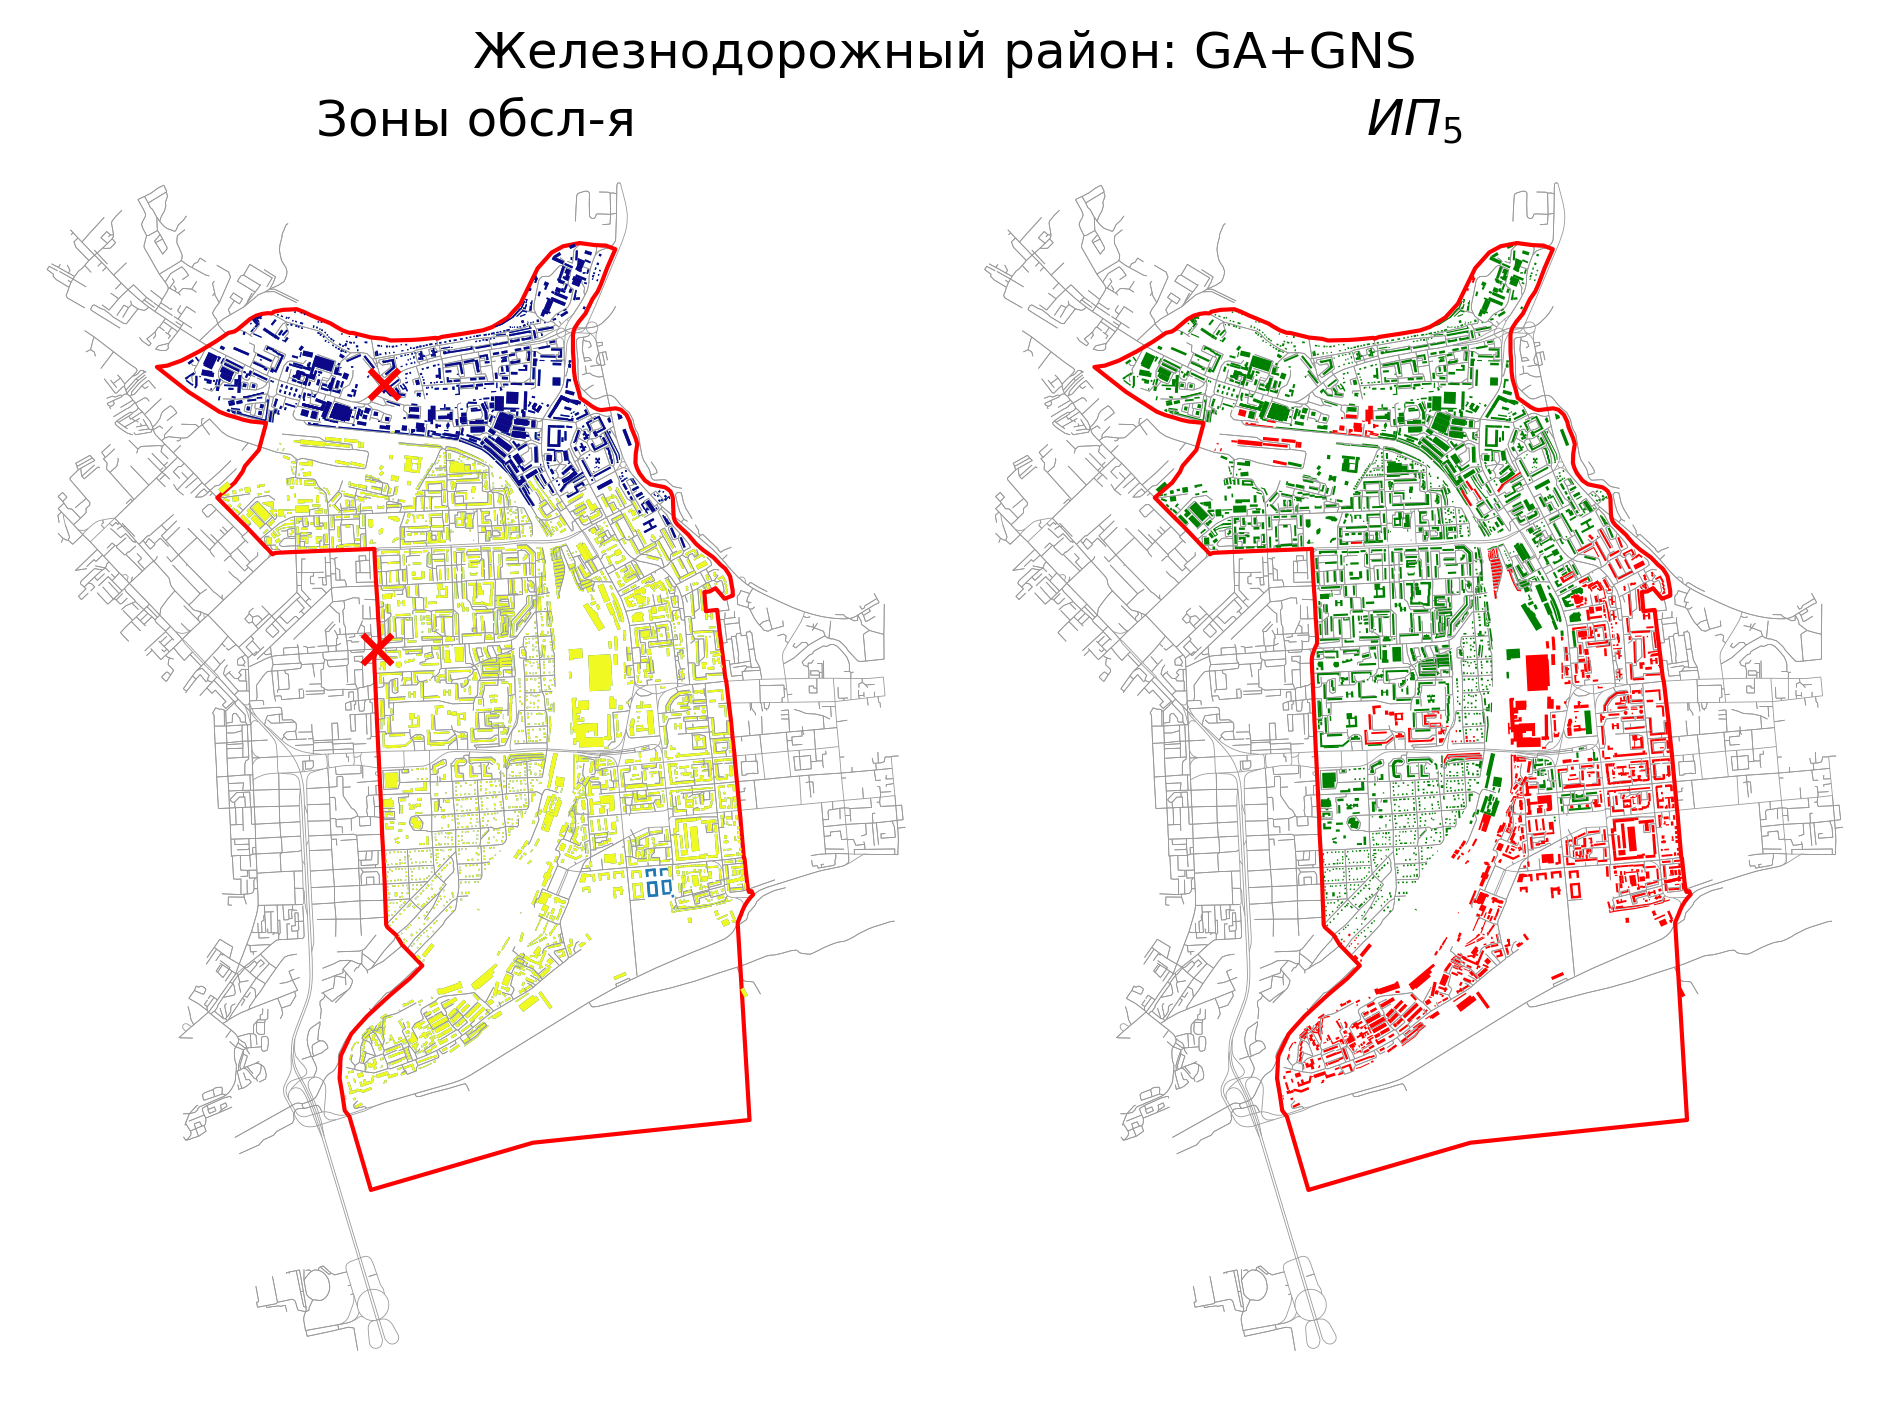



МЕТРИКА: 70.9939865581889 | ПОДРАЗДЕЛЕНИЙ 2
ВРЕМЯ ОДНОГО РАСЧЕТА: 362.15 сек
 
Кировский район
Узлов 2607

 # Расчет GNS
--------------------------------------------------------------------------------
4 4.880347041964957
Итерация: 0 | Лучшая метрика: 4.88034704196495 | Подразделений: 2
Текущий ИП-5: 66.52386780905752 90
4 3.7031194403374563
Итерация: 1 | Лучшая метрика: 3.7031194403374563 | Подразделений: 3
Текущий ИП-5: 88.55569155446756 90
4 3.4734521657219206
Итерация: 2 | Лучшая метрика: 3.4734521657219206 | Подразделений: 4
Текущий ИП-5: 92.31946144430844 90
Текущий ИП-5: 92.31946144430844 90
Текущий ИП-5: 76.49938800489596 90
Текущий ИП-5: 76.49938800489596 90
Текущий ИП-5: 76.49938800489596 90
 -> 1 Подразделений: 3 76.49938800489596 130.82
4 4.3540116624536775
Итерация: 0 | Лучшая метрика: 4.3540116624536775 | Подразделений: 2
Текущий ИП-5: 78.4577723378213 90
4 3.9088852183288716
Итерация: 1 | Лучшая метрика: 3.9088852183288716 | Подразделений: 3
Текущий ИП-5: 86.8115055079

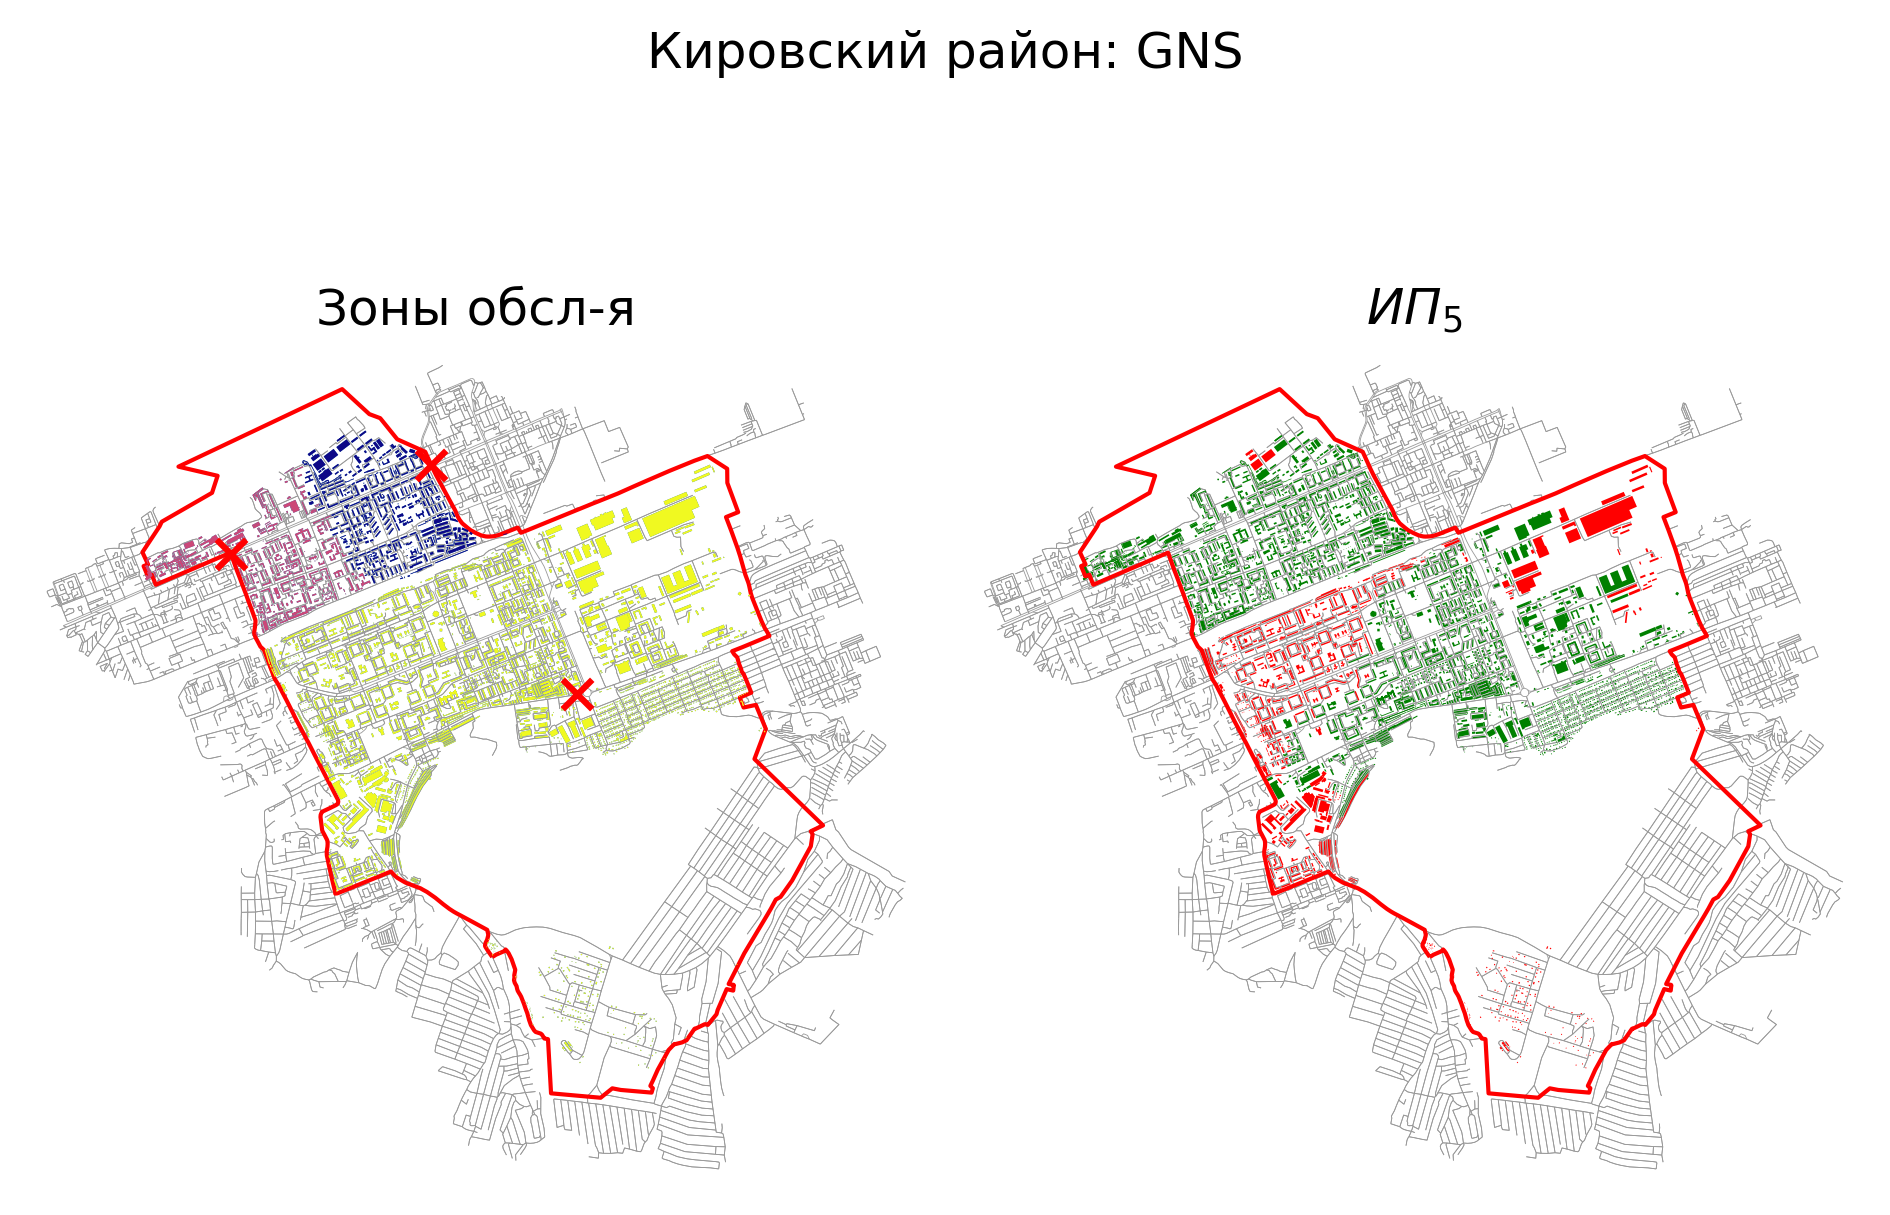



МЕТРИКА: 77.0501835985312 | ПОДРАЗДЕЛЕНИЙ 3
ВРЕМЯ ОДНОГО РАСЧЕТА: 130.82 сек

 # Расчет GA+GNS
--------------------------------------------------------------------------------
2 4.151659963131978етрика: 4.294756314566601 | Текущая метрика: 4.294756314566601 |             
Итерация: 0 | Лучшая метрика: 4.151659963131978 | Подразделений: 2
Текущий ИП-5: 79.68176254589963 90
2 3.604633028315657етрика: 3.7010790729908982 | Текущая метрика: 3.7010790729908982 |           
Итерация: 1 | Лучшая метрика: 3.604633028315657 | Подразделений: 3
Текущий ИП-5: 76.16279069767442 90
2 3.131956525304538етрика: 3.2586580999192742 | Текущая метрика: 3.2586580999192742 |           
Итерация: 2 | Лучшая метрика: 3.131956525304538 | Подразделений: 4
Текущий ИП-5: 93.78824969400245 90
Текущий ИП-5: 93.78824969400245 90
Текущий ИП-5: 54.834761321909426 90
Текущий ИП-5: 54.834761321909426 90
Текущий ИП-5: 54.834761321909426 90
 -> 1 Подразделений: 3 54.834761321909426 546.48
2 4.151659963131978етрика: 4.3320

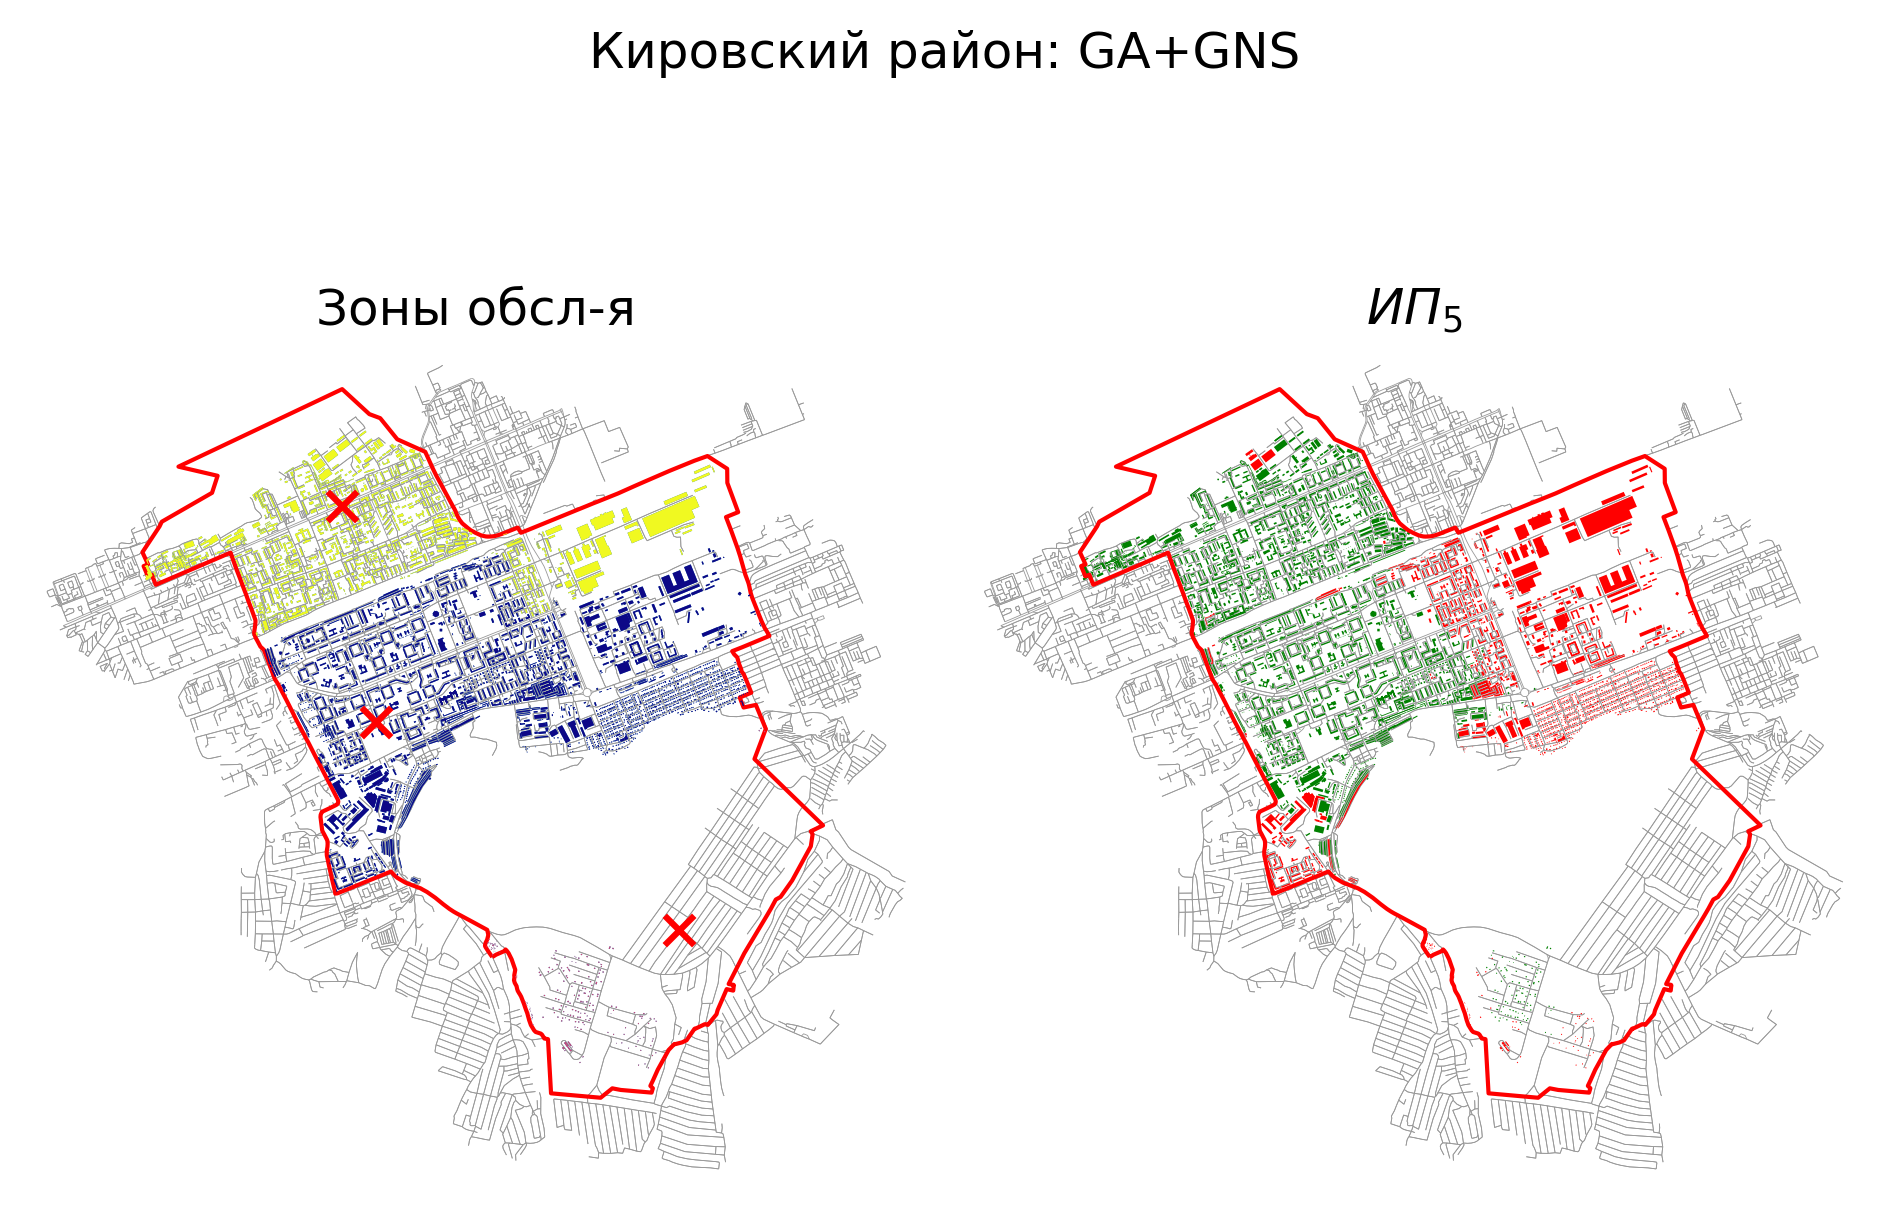



МЕТРИКА: 78.42717258261933 | ПОДРАЗДЕЛЕНИЙ 3
ВРЕМЯ ОДНОГО РАСЧЕТА: 546.48 сек
 
Ленинский район
Узлов 4356

 # Расчет GNS
--------------------------------------------------------------------------------
4 6.092359244017038
Итерация: 0 | Лучшая метрика: 6.092359244017038 | Подразделений: 2
Текущий ИП-5: 43.668763102725364 90
4 5.954393640688488
Итерация: 1 | Лучшая метрика: 5.954393640688488 | Подразделений: 3
Текущий ИП-5: 43.689727463312366 90
4 5.685072463222087
Итерация: 2 | Лучшая метрика: 5.685072463222087 | Подразделений: 4
Текущий ИП-5: 53.689727463312366 90
4 4.7010768024783856
Итерация: 3 | Лучшая метрика: 4.7010768024783856 | Подразделений: 5
Текущий ИП-5: 63.522012578616355 90
4 4.517646525396724
Итерация: 4 | Лучшая метрика: 4.517646525396724 | Подразделений: 6
Текущий ИП-5: 74.61215932914047 90
4 4.280039885474071
Итерация: 5 | Лучшая метрика: 4.280039885474071 | Подразделений: 7
Текущий ИП-5: 78.25995807127883 90
4 3.8996756090391327
Итерация: 6 | Лучшая метрика: 3.8996

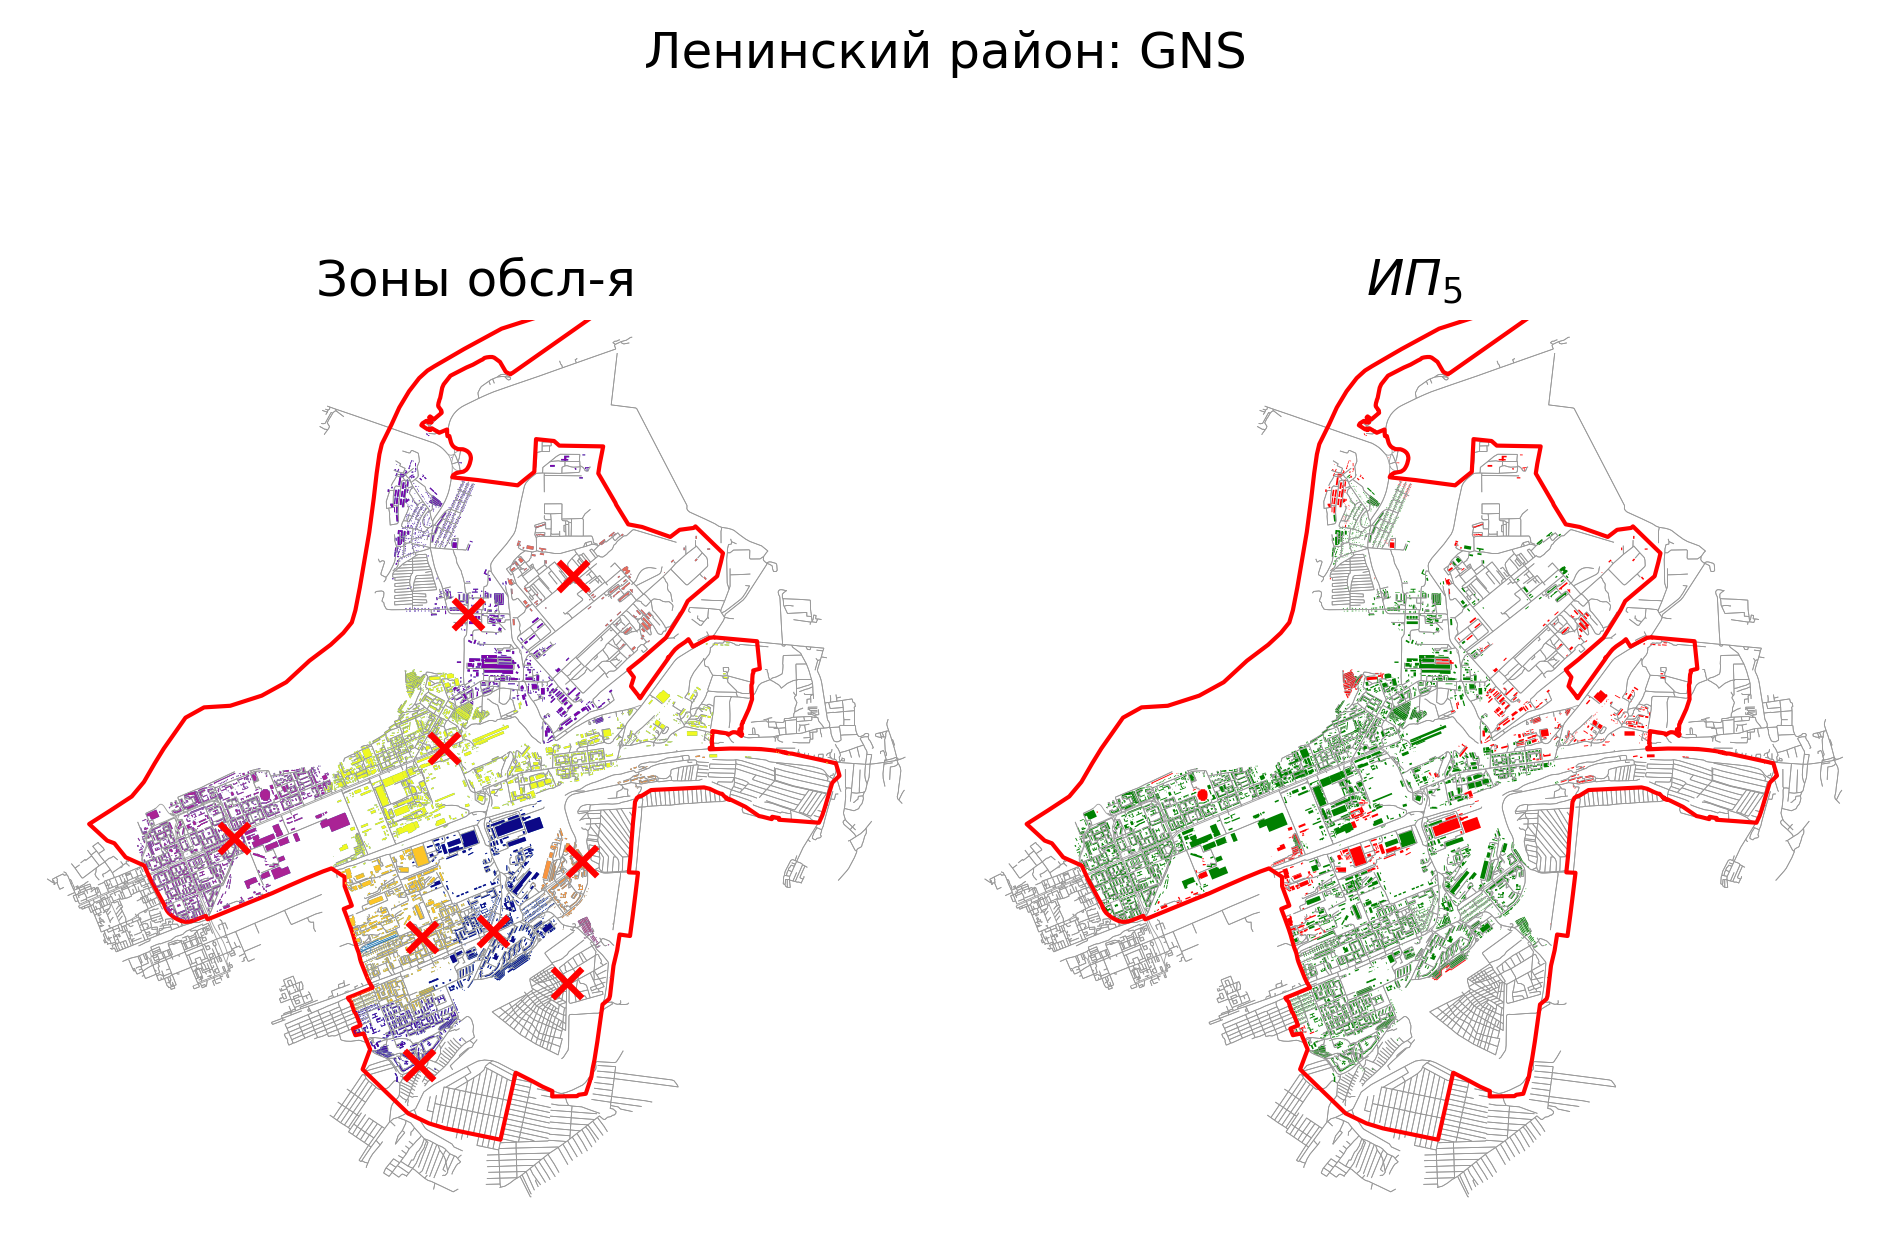



МЕТРИКА: 86.49895178197065 | ПОДРАЗДЕЛЕНИЙ 9
ВРЕМЯ ОДНОГО РАСЧЕТА: 325.7 сек

 # Расчет GA+GNS
--------------------------------------------------------------------------------
2 5.8196356053399185трика: 6.036809372778711 | Текущая метрика: 6.036809372778711 |             
Итерация: 0 | Лучшая метрика: 5.8196356053399185 | Подразделений: 2
Текущий ИП-5: 50.83857442348008 90
2 5.336857391207531етрика: 5.598420464146187 | Текущая метрика: 5.598420464146187 |           
Итерация: 1 | Лучшая метрика: 5.336857391207531 | Подразделений: 3
Текущий ИП-5: 55.55555555555556 90
2 4.833246884067013етрика: 4.985763481817479 | Текущая метрика: 4.985763481817479 |             
Итерация: 2 | Лучшая метрика: 4.833246884067013 | Подразделений: 4
Текущий ИП-5: 67.44234800838575 90
2 4.451982644742801етрика: 4.743853888631382 | Текущая метрика: 4.743853888631382 |             
Итерация: 3 | Лучшая метрика: 4.451982644742801 | Подразделений: 5
Текущий ИП-5: 75.36687631027253 90
2 4.293634642475981етрика: 

KeyboardInterrupt: 

In [10]:
# # Из кэша
# tdfexisted = pd.read_csv('lscp.csv')
# tdfexisted = tdfexisted.set_index('Unnamed: 0')

from diss.lscp import BestNodesGADiss, BestNodesSADiss
from genesis.lscp import LSCPCommon, drop_trash_points
from genesis.core import StateBase, StopCaseBase
from genesis.mclp import NodesMetric
from genesis.tools import list_dict_concat


runs_count = 3
units_count = 2
target_ip = 90
ip_val_main = 5

# Потом удалить!
def drop_trash_points(env,
                    state_function: StateBase,
                    metric_function: MetricBase,
                    stop_case_function: StopCaseBase,
                    dynamic_nodes,
                    static_nodes=None,
                    area=None,
                    ):
    '''
    Функция отброса мусорных размещений.
    В данном случае используется жадное удаление

    
    '''
    for node in dynamic_nodes:
        tmp = dynamic_nodes.copy()
        tmp.pop(node)

        if static_nodes is None:
            all_nodes = dynamic_nodes
        else:
            all_nodes = list_dict_concat(tmp, static_nodes)

        metric = NodesMetric(state_function, metric_function)(env, list(all_nodes.keys()), area=area)
        if stop_case_function(value=metric,
                            iteration=0,
                            best_metric=metric,
                            dynamic_nodes=dynamic_nodes,
                            static_nodes=static_nodes):
            dynamic_nodes = tmp
    
    if static_nodes is None:
        all_nodes = dynamic_nodes
    else:
        all_nodes = list_dict_concat(tmp, static_nodes)
    metric = NodesMetric(state_function, metric_function)(env, list(all_nodes.keys()), area=area)
    
    return dynamic_nodes, metric

def save_experiment_state_lscp():
    # Сохранение итогов в основные словари:
    main_times_list[district+' время'] = times_list
    main_metric_list[district+' метрика'] = metric_list
    main_units_count_list[district+' подразделений'] = units_count_list
    # ------------------------------
    tdf = pd.DataFrame({**main_times_list, **main_metric_list, **main_units_count_list})
    tdf.to_csv('lscp.csv')

# STOPCASE Здесь!
def stop_case_function(value,
                        iteration,
                        best_metric,
                        dynamic_nodes,
                        static_nodes,
                        target_ip=target_ip,
                        ip_val=ip_val_main):
    # times, _ = FirstArrivalUnitState()(env=g, points=dynamic_nodes, area=area_nodes)
    # ip = CoverIndexBuilding(buildings=b, ip_val=ip_val)(state=times, area=area_nodes)
    ip = NodesMetric(FirstArrivalUnitState(),
                     CoverIndexBuilding(buildings=b, ip_val=ip_val)
                     )(env=g, nodes=list(dynamic_nodes.keys()), area=area_nodes)
    print(f'Текущий ИП-{ip_val_main}:', ip, target_ip)
    if ip >= target_ip:
        return True
    return False

main_times_list = {}            # Время одной итерации
main_metric_list = {}           # Лучшая метрика полученная алгоритмом
main_units_count_list = {}      # Количество подразделений предложенное алгоритмом

for district, scope in scopes.items():
    print(' ')
    print('='*80)
    print(district)
    g = scopes[district][1]
    b = scopes[district][2]
    nodes = ox.graph_to_gdfs(g, edges=False)
    area_nodes = nodes.within(scopes[district][0])
    nodes_list=set(nodes[area_nodes].index)
    print('Узлов', sum(area_nodes))
    print('='*80)

    # функция метрики спроса
    metric_demand = ArrivalTime()  # Demand(b, buildings_demand_field='kfpo_spros')  #! учет влияния кол-ва подразделений зашит внутри GA и SA
    metric_ipbuild = CoverIndexBuilding(b, ip_val=ip_val_main)

    # Списки результатов расчета
    times_list = {}             # Время одной итерации
    metric_list = {}            # Лучшая метрика полученная алгоритмом
    units_count_list = {}       # Количество подразделений предложенное алгоритмом
    t = TimeCheckPoint()
    t2 = TimeCheckPoint()


    # Расчет GNS
    # ============================================================================
    alg_name = 'GNS'
    print('\n', '# Расчет {}'.format(alg_name))
    print('-'*80)
    try:
        times_list[alg_name] = tdfexisted.loc[alg_name][district+' время']
        metric_list[alg_name] = tdfexisted.loc[alg_name][district+' метрика']
        units_count_list[alg_name] = tdfexisted.loc[alg_name][district+' подразделений']
        if np.isnan(times_list[alg_name]):
            raise ValueError('Значение не было вычислено!')

        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        # здесь сам расчет
        def iter_func(i, best_metric, **kwds):
            print(i, best_metric, end='\r')
        def mclp_end_function(iteration, best_metric, dynamic_nodes, **kwargs):
            print(f'\nИтерация: {iteration} |', f'Лучшая метрика: {best_metric} |', f'Подразделений: {len(dynamic_nodes)}')
        # metric_ipbuild = CoverIndexBuilding(b, ip_val=ip_val_main)
        # stop_case = MoreEqualStopCase(target_ip)
        bnhc = BestNodeHillClimbingHD(state_function=FirstArrivalUnitState(),
                        metric_function=metric_demand,  #metric_ipbuild,  #metric_demand,
                        )
        mclpgns = BestNodesKoptG(state_function=FirstArrivalUnitState(),
                        metric_function=metric_demand, #metric_ipbuild,
                        best_point_function=bnhc,
                        iterations=5,
                        iter_calc_end_function=iter_func,
                        # stop_case_function = stop_case
                        )
        point_selector = RandomNodesSelector(nodes_list=nodes_list)
        lscp = LSCPCommon(mclp_function = mclpgns,
                     point_selector = point_selector,
                    stop_case_function = stop_case_function,  # stop_case,
                    start_names_index = units_count+1,
                    names_pattern='псч {}',
                    after_mclp_function=mclp_end_function,
                    )
        

        # bn_times = []
        # bn_metrics = []
        # bn_units = []
        bn_times = None
        bn_metrics = None
        bn_units = None
        t()
        for i in range(runs_count):      # результат детерминирован, поэтому смысла в постоянных перерасчетах нет
            t2()

            start_state = {random.sample(list(nodes_list), k=1)[0]:f'псч {i+1}' for i in range(units_count)}
            optimal_nodes, best_metric = lscp(env=g,
                            dynamic_nodes=start_state,
                            area=area_nodes,
                            )
            optimal_nodes, best_metric = drop_trash_points(g,
                                                           FirstArrivalUnitState(),
                                                           metric_ipbuild,
                                                           stop_case_function,
                                                           optimal_nodes,
                                                           area=area_nodes)
            # bn_times.append(t2(False))
            # bn_metrics.append(best_metric)
            # bn_units.append(len(optimal_nodes))
            # print(i+1, 'Подразделений:', len(optimal_nodes), best_metric, t2(), end='\r')
            if bn_units is None:
                bn_times = t2(False)
                bn_metrics = best_metric
                bn_units = optimal_nodes
            else:
                # if metric_ipbuild.compare(bn_metrics, best_metric):
                if len(optimal_nodes) < len(bn_units):
                    bn_times = t2(False)
                    bn_metrics = best_metric
                    bn_units = optimal_nodes                    
            print(' ->', i+1, 'Подразделений:', len(optimal_nodes), best_metric, t2())
        time_spent = t()

        # Сохраняем результат вычисления
        # times_list[alg_name] = np.mean(bn_times)
        # metric_list[alg_name] = np.max(bn_metrics)
        # units_count_list[alg_name] = np.min(bn_units)
        times_list[alg_name] = bn_times
        metric_list[alg_name] = best_metric
        units_count_list[alg_name] = len(bn_units)
        plot_g2(f'{district}: {alg_name}', g, b, districts.loc[[district]], nodes=optimal_nodes, t_max=ip_val_main)

        save_experiment_state_lscp()
        print('\n')
    print(f'МЕТРИКА: {metric_list[alg_name]}', '| ПОДРАЗДЕЛЕНИЙ', units_count_list[alg_name])
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {times_list[alg_name]} сек')


    # Расчет GA+GNS
    # ============================================================================
    alg_name = 'GA+GNS'
    print('\n', '# Расчет {}'.format(alg_name))
    print('-'*80)
    try:
        times_list[alg_name] = tdfexisted.loc[alg_name][district+' время']
        metric_list[alg_name] = tdfexisted.loc[alg_name][district+' метрика']
        units_count_list[alg_name] = tdfexisted.loc[alg_name][district+' подразделений']
        if np.isnan(times_list[alg_name]):
            raise ValueError('Значение не было вычислено!')

        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        # здесь сам расчет
        def iter_func(i, best_metric, **kwds):
            print(i, best_metric, end='\r')
        def epoch_end_function(epoch, best_metric, cur_metric, **kwargs):
            print(f'Эпоха: {epoch} |', f'Лучшая метрика: {best_metric} |', f'Текущая метрика: {cur_metric} |', ' '*10, end='\r')
        def mclp_end_function(iteration, best_metric, dynamic_nodes, **kwargs):
            print(f'\nИтерация: {iteration} |', f'Лучшая метрика: {best_metric} |', f'Подразделений: {len(dynamic_nodes)}')

        # metric_ipbuild = CoverIndexBuilding(b, ip_val=ip_val_main)
        bnhc = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                    metric_function=metric_demand,  #metric_ipbuild,  #metric_demand,                      
                        )
        kopt = BestNodesKoptG(FirstArrivalUnitState(),
                            metric_function=metric_demand, #metric_ipbuild,
                            best_point_function=bnhc,
                            iterations=3,
                            iter_calc_end_function=iter_func,
                            )
        point_selector = RandomNodesSelector(nodes_list=nodes_list)
        # metric_ipbuild = CoverIndexBuilding(b, ip_val=ip_val_main)
        mclp = BestNodesGAKopt(FirstArrivalUnitState(),
                            metric_function=metric_demand, #metric_ipbuild,
                            kopt_function = kopt,
                            node_selector = point_selector,
                            population_size=75,
                            elite_size = 15,
                            epochs = 10,
                            # epochs = 1,
                            mutation_rate = 0.5,
                            mutation_max_count=3,
                            epoch_end_function = epoch_end_function,
                            # stop_case_function=NSameStopCase(15),
        )
        lscp = LSCPCommon(mclp_function = mclp,
                     point_selector = point_selector,
                    stop_case_function = stop_case_function,  # MoreEqualStopCase(target_ip),
                    start_names_index = units_count+1,
                    names_pattern='псч {}',
                    after_mclp_function=mclp_end_function,
                    )
        
        start_state = {random.sample(list(nodes_list), k=1)[0]:f'псч {i}' for i in range(units_count)}

        bn_times = None
        bn_metrics = None
        bn_units = None
        t()
        for i in range(runs_count):
            t2()
            optimal_nodes, best_metric = lscp(env=g, 
                                    dynamic_nodes=start_state,
                                    area=area_nodes,
                                    )
            optimal_nodes, best_metric = drop_trash_points(g,
                                                           FirstArrivalUnitState(),
                                                           metric_ipbuild,
                                                           stop_case_function,
                                                           optimal_nodes,
                                                           area=area_nodes)
            # bn_times.append(t2(False))
            # bn_metrics.append(best_metric)
            # bn_units.append(len(optimal_nodes))
            if bn_units is None:
                bn_times = t2(False)
                bn_metrics = best_metric
                bn_units = optimal_nodes
            else:
                # if metric_ipbuild.compare(bn_metrics, best_metric):
                if len(optimal_nodes) < len(bn_units):
                    bn_times = t2(False)
                    bn_metrics = best_metric
                    bn_units = optimal_nodes                    
            print(' ->', i+1, 'Подразделений:', len(optimal_nodes), best_metric, t2())
        time_spent = t()

        # Сохраняем результат вычисления
        times_list[alg_name] = bn_times
        metric_list[alg_name] = best_metric
        units_count_list[alg_name] = len(bn_units)
        plot_g2(f'{district}: {alg_name}', g, b, districts.loc[[district]], nodes=bn_units, t_max=ip_val_main)

        save_experiment_state_lscp()
        print('\n')
    print(f'МЕТРИКА: {metric_list[alg_name]}', '| ПОДРАЗДЕЛЕНИЙ', units_count_list[alg_name])
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {times_list[alg_name]} сек')


In [ ]:
bn_units

In [ ]:
def plot_g3(name, g, b, poly, nodes, t_max=5, **kwds):
    
    fig, (ax, ax2) = plt.subplots(1,2, dpi=300, **kwds)

    # ax.set_title('Зоны обсл-я')
    ax.set_axis_off()
    ax.set_facecolor('white')
    poly.plot(color='none', edgecolor='r', linewidth=1, ax=ax)
    ox.plot_graph(g, node_size=0, edge_linewidth=0.2, ax=ax, show=False)
    b.plot(ax=ax)



    ox.plot_graph(g, node_size=0, edge_linewidth=0.2, ax=ax2, show=False)
    times, nearest = FirstArrivalUnitState()(G, points=nodes)
    merged_df = pd.merge(b,
                pd.concat([times, nearest], axis=1),
                left_on=['node'],
                right_index=True)
    merged_df['time_color'] = ['green' if t<=t_max else 'red' for t in merged_df['times']]
    merged_df.plot(ax=ax, column='nearest', cmap='plasma')
    merged_df.plot(ax=ax2, color=merged_df['time_color'])
    poly.plot(color='none', edgecolor='r', linewidth=1, ax=ax2)

    g_nodes = ox.graph_to_gdfs(g, edges=False).loc[list(nodes.keys())]
    g_nodes.plot(ax=ax, color='r', markersize=50, marker='x', **kwds)
    
    # ax2.set_title(f'$ИП_{t_max}$')
    ax2.set_axis_off()

    # fig.suptitle(name)

    # fig.tight_layout()
    plt.show()

# ТЕСТ, потом удалить!:
district = 'Центральный район'
g = scopes[district][1]
b = scopes[district][2]
# nodes = {list(g.nodes())[100]: '1', list(g.nodes())[200]: '2', list(g.nodes())[1000]: '3'}
plot_g3(district, g, b, districts.loc[[district]], nodes=bn_units)

# Черновики

In [ ]:
# Печать карты
def plot_scope_result(g:nx.MultiDiGraph,
                      district:gpd.GeoDataFrame,
                      point:list,
                      buildings:pd.DataFrame,
                      ax=None):
    nodes = ox.graph_to_gdfs(g, edges=False)
    if ax is None:
        fig, ax = ox.plot_graph(g, edge_linewidth=0.2, node_size=0, show=False, bgcolor='white')
    district.boundary.plot(ax=ax, color='r')
    buildings.plot(ax=ax)
    nodes.loc[point].plot(ax=ax, markersize=25, color='red')

    return 1, 2

d = timing(plot_scope_result(g, districts.loc[[district]], [best_node], b))
d

In [ ]:
state, _ = FirstArrivalUnitState()(g, points={best_node:'best'})
area = area_nodes
if isinstance(state, pd.Series):
    state_c = state.loc[area]
else:
    state_c = [x for x in state if x in area]

# Расчет метрики по спросу
merged_df = pd.merge(b,
                    state_c,
                    left_on='node',
                    right_index=True)

merged_df['demand_val'] = merged_df['node'] / merged_df['times']

In [ ]:
def plot_scope_result(g:nx.MultiDiGraph,
                      district:gpd.GeoDataFrame,
                      point:list,
                      buildings:pd.DataFrame,
                      ax=None):
    nodes = ox.graph_to_gdfs(g, edges=False)
    if ax is None:
        fig, ax = ox.plot_graph(g, edge_linewidth=0.2, node_size=0, show=False, bgcolor='white')
    district.boundary.plot(ax=ax, color='r')
    buildings.plot(ax=ax, column='times', cmap=CMAP_GrGldRd, legend=True)
    nodes.loc[point].plot(ax=ax, markersize=25, color='red')

plot_scope_result(g, districts.loc[[district]], [best_node], merged_df)

#### Тест HC с исследованием областей

In [ ]:
bnhc = BestNodeHillClimbing(FirstArrivalUnitState(), metric_demand)

bn_list = []
bn_metrics = []
i=1

size=200
split_list = [list(nodes_list)[i:i+size] for i in range(0, len(nodes_list), size)]

ts = time.time()
while time.time() - ts < etalon_time:
    tcs = time.time()
    best_cur_node = None
    best_cur_metric = 0
    j=1
    for nodes_part in split_list:
        start_node = random.choice(nodes_part)
        best_node, best_metric = bnhc(env=g, area=area_nodes, start_node=start_node)
        if best_metric > best_cur_metric:
            best_cur_node = best_node
            best_cur_metric = best_metric
        print(f'{i}:', j, 'из', len(split_list), best_cur_metric, end='\r')
        j+=1

    bn_list.append(best_cur_node)
    bn_metrics.append(best_cur_metric)
    tcd = time.time() - tcs
    print('\n', i, best_cur_node, best_cur_metric, round(tcd, 2), ' '*10) #, end='\r')
    i+=1

tf = time.time()
td = round(tf-ts, 2)
print(f'ВРЕМЯ: {td} сек')

correct_results = bn_list.count(etalon_node)
print(f'КОРРЕКТНОСТЬ: {correct_results} из {len(bn_list)}')
print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {td/len(bn_list)} сек')

In [ ]:
random.choices(list(nodes_list), k=5)

In [ ]:
# from genesis.best_points import NodeMetric
# from genesis.core import StateBase


# class BestNodeBee(BestNodeHillClimbing):
#     '''
#         Поиск лучших узлов графа с использованием алгоритма пчелиной колонии
#         (Artificial Bee Colony Optimization, ABC).
#         Могут быть возвращены только узлы из которых можно попасть в большую часть 
#         других узлов графа.
#         Если таковых узлов нет, возвращается ошибка некорректности графа.
#         (граф должен быть проверен на корректность прежде чем будет передан функции)

#         Узлы для которых метрика не может быть вычислена (например слабо связанные
#         с основным графом) не учитываются.

#         ## Область применения
#         Определение размещения одного узла с наилучшими показателями.
#         Дает достаточно точное решение. Хорошо подходит для больших графов.
#     '''
#     def __init__(self,
#                  state_function: StateBase,
#                  metric_function: MetricBase,
#                  appr_val: float = 0.95,
#                  all_neighbors: bool=True,
#                  scouts_count: int = 100,
#                  best_scouts_count: int = 5,
#                 #  after_local_jump_function: callable = None,
#                  **kwargs) -> None:
#         '''
#         ## Аргументы
#         `state_function`: StateBase
#             функция расчета состояния окружения
#         `metric_function`: MetricBase
#             Функция расчета метрики
#         `appr_val`: = 0.95
#             Доля узлов графа, покрытие которой считается приемлемой для принятия расчетной метрики. 
#             Если при расчете метрик, из стартового узла (узлов) достижимо меньшее количество узлов,
#             то такой узел не рассматривается.
#         `all_neighbors`: bool=True
#             Если True рассматриваются все узлы смежные с рассчитываемым узлом.
#             Если False - только исходящие.
#         `scouts_count`: int=100
#             Количество пчел-разведчиков.
#         `best_scouts_count`: int=5
#             Количество лучших пчел-разведчиков.
#             Для них производится дальнейшая оптимизация.
        
#         '''
#         self.node_metric_func = NodeMetric(state_function,
#                                            metric_function,
#                                            appr_val,
#                                            err_val=None,
#                                            **kwargs)
#         self.scouts_count = scouts_count
#         self.best_scouts_count = best_scouts_count
#         super().__init__(state_function,
#                          metric_function,
#                          appr_val=appr_val,
#                          all_neighbors=all_neighbors,
#                          **kwargs)


#     def __call__(self,
#                  env:nx.MultiDiGraph,
#                  area=None,
#                  nodes_list:set=None,
#                  **kwargs) -> tuple[int | None, float | None]:
#         '''
#         Реализация: `scouts_count` пчел-разведчиков случайным образом проверяют узлы
        
#         при помощи BestNodesHillClimbing ищется лучшая точка, 
#         после чего обезьяна прыгает по ближайшим вершинам и вновь использует BestNodesHillClimbing.

#         Так, пока не будет найден глобальный оптимум или не будет достигнуто количество итераций.

#         ## Аргументы
#         `env`:nx.MultiDiGraph
#             Граф улично-дорожной сети
#         `area`: pd.Series = None
#             Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
#             Если не указана, расчет производится для всех узлов графа.
#         `nodes_list`:set=None
#             Множество узлов графа которые будут рассмотрены в качестве кандидатов.
#             Если не указан, то будут рассмотрены все узлы графа.

#         ## Возвращает
#         `best_node`: int, `best_metric`: float
#             Лучший узел, лучшая метрика
#         '''

#         if not isinstance(env, nx.MultiDiGraph):
#             raise TypeError("Тип переменной `env` должен быть MultiDiGraph!")
#         if not area is None and not isinstance(area, pd.Series):
#             raise TypeError(f'Аргумент `area` должен иметь тип `pd.Series`! Имеет {type(area)}')

#         # Если списка узлов изначально не передано, рассматриваются все узлы графа
#         if nodes_list is None:
#             nodes_list = env.nodes()

#         # 1. Разведка местности
#         t_list = []
#         t_metric = []
#         for start_node in random.choices(list(nodes_list), k=self.scouts_count):
#             start_metric = self.node_metric_func(env=env, area=area, node=start_node)
#             t_list.append(start_node)
#             t_metric.append(start_metric)
        
#         # 2. Выбираем результаты лучших пчел-разведчиков
#         tdf = pd.DataFrame({'node':t_list, 'metric':t_metric})
#         if self.metric_function.compare(1,2)==2:
#             tdf = tdf.sort_values('metric', ascending=False)
#         else:
#             tdf = tdf.sort_values('metric', ascending=True)
#         # tdf.sort_values('metric', ascending=self.metric_function.compare(1,2)==2)
#         # print(tdf['metric'][:10])

#         # 3. Для каждого из лучших результатов пытаемся найти еще лучшие значения метрики в окрестности
#         best_node = None
#         best_metric  = None
#         for node in tdf['node'][:self.best_scouts_count]:
#             cur_node, cur_metric = super().__call__(
#                     env=env,
#                     start_node=node,
#                     area=area,
#                     **kwargs,
#                     )

#             if best_node is None:
#                 best_node, best_metric = cur_node, cur_metric
#             else:
#                 if best_node != cur_node and \
#                         self.metric_function.compare(best_metric, cur_metric) == cur_metric:
#                     best_node, best_metric = cur_node, cur_metric

#         return best_node, best_metric

In [ ]:
from genesis.best_points import BestNodeBee

bnabc = BestNodeBee(FirstArrivalUnitState(),
                    metric_demand,
                    # scouts_count=150,
                    # best_scouts_count=3,
                    )

ts = time.time()
bn_list = []
bn_metrics = []
i=1
while time.time() - ts < etalon_time:
# while i < 5:
    print(i, end=':')
    tcs = time.time()

    best_node, best_metric = bnabc(env=g, area=area_nodes, nodes_list=nodes_list)

    bn_list.append(best_node)
    bn_metrics.append(best_metric)
    tcd = time.time() - tcs
    print(best_node, best_metric, round(tcd, 2))
    i+=1

tf = time.time()
td = round(tf-ts, 2)
print(f'ВРЕМЯ: {td} сек')

correct_results = bn_list.count(etalon_node)
print(f'КОРРЕКТНОСТЬ: {correct_results} из {len(bn_list)}')
print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {td/len(bn_list)} сек')

In [ ]:
from genesis.best_points import NodeMetric


bnhc = BestNodeHillClimbing(FirstArrivalUnitState(), metric_demand)
node_metric = NodeMetric(FirstArrivalUnitState(), metric_demand)


bn_list = []
bn_metrics = []
i=1

k = 100
k_best = 5

ts = time.time()
while time.time() - ts < etalon_time:
# while i < 10:
    tcs = time.time()
    best_cur_node = None
    best_cur_metric = 0

    t_list = []
    t_metric = []
    j=1
    for start_node in random.choices(list(nodes_list), k=k):
        start_metric = node_metric(env=g, area=area_nodes, node=start_node)
        if start_metric > best_cur_metric:
            best_cur_node = start_node
            best_cur_metric = start_metric
        t_list.append(start_node)
        t_metric.append(start_metric)

        print(f'{i}:', j, 'из', k, best_cur_metric, start_metric,  end='\r')
        j+=1

    tdf = pd.DataFrame({'node':t_list, 'metric':t_metric}).sort_values('metric', ascending=False)
    
    best_cur_node = None
    best_cur_metric = 0
    j=1
    for node in tdf['node'][:k_best]:
        best_node, best_metric = bnhc(env=g, area=area_nodes, start_node=node)
        if best_metric > best_cur_metric:
            best_cur_node = best_node
            best_cur_metric = best_metric
        print(f'{i}:', j, 'из', k_best, best_cur_metric, end='\r')
        j+=1

    bn_list.append(best_cur_node)
    bn_metrics.append(best_cur_metric)
    tcd = time.time() - tcs
    print('\n', i, best_cur_node, best_cur_metric, round(tcd, 2), ' '*10) #, end='\r')
    i+=1

tf = time.time()
td = round(tf-ts, 2)
print(f'ВРЕМЯ: {td} сек')

correct_results = bn_list.count(etalon_node)
print(f'КОРРЕКТНОСТЬ: {correct_results} из {len(bn_list)}')
print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {td/len(bn_list)} сек')

    ВРЕМЯ: 347.34 сек
    КОРРЕКТНОСТЬ: 17 из 20
    ВРЕМЯ ОДНОГО РАСЧЕТА: 17.366999999999997 сек

In [ ]:
size=300
split_list = [list(nodes_list)[i:i+size] for i in range(0, len(nodes_list), size)]
for sl in split_list:
    print(len(sl))